# Проверка отчётов по диалогам зарплатного проекта

Этот notebook **воспроизводит** ключевые цифры и выводы двух отчётов:

1. *Анализ исторических диалогов* — общий взгляд на 8 386 звонков.
2. *Анализ исторических диалогов в разрезе менеджеров* — сравнение менеджеров между собой.

**Что нужно для запуска**
1. Загрузить в Colab файл `Датасет диалогов КМ ЗП 01.01.26-18.04.26.xlsx`
   (кнопка «папка» слева → перетащить).
2. *(Опционально)* Если хочется пересчитать LLM-аудит на свежей выборке:
   - В Colab открыть боковую панель **🔑 Secrets** и добавить секрет с именем `OPENAI_API_KEY`
     (включить переключатель «Notebook access»).
   - В разделе 14 поставить `RUN_LLM_AUDIT = True` и запустить блок.
   - Без этого все основные числа (разделы 1–13) всё равно посчитаются.
3. Run all (Ctrl+F9).

**Структура**

| Раздел | Что проверяем | Откуда вывод |
|---|---|---|
| 1 | Структура датасета и парсинг полей-списков | подготовка |
| 2 | Воронка очистки 8 386 → ~5 800 пригодных | Отчёт 1, §2.2 |
| 3 | Распределение исходов: 25/38/37 (Согласие/Перенос/Отказ) | Отчёт 1, §1, §2.3 |
| 4 | Успешные звонки длиннее, длинное вступление мешает | Отчёт 1, §3 |
| 5 | Каналы подключения: СберБизнес доминирует | Отчёт 1, §2.4 |
| 6 | «Волшебные слова» — почему так считать нельзя | Отчёт 1, §5.1 |
| 7 | Конфаундер «тип задачи»: 84 % vs 13 % | Отчёт 2, §2.3 |
| 8 | Сглаженная конверсия + Wilson | Отчёт 2, §3 |
| 9 | Группы ТОП / MID / НИЗ менеджеров | Отчёт 2, §4 |
| 10 | Поведенческие отличия (Mann-Whitney) | Отчёт 2, §6 |
| 11 | Парадокс СберБизнеса (слово vs навигация) | Отчёт 2, §6.2, §9 |
| 12 | Реакция на первое возражение | Отчёт 2, §6.3 |
| 13 | Spearman-корреляции и ловушки причинности | Отчёт 2, §5, §9 |
| 14 | Опциональный LLM-аудит regex-разметки | дополнительно |
| 15 | Сводная таблица «вывод → проверка → результат» | финал |

## 1. Подготовка окружения и датасета

In [33]:
# Установка недостающих пакетов в Colab. На локальном Jupyter обычно ничего не ставится.
import importlib, subprocess, sys

for pkg in ("openpyxl", "scipy", "requests"):
    try:
        importlib.import_module(pkg)
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("Зависимости готовы")

Зависимости готовы


In [34]:
import ast
import json
import math
import os
import re
import textwrap
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.stats import mannwhitneyu, spearmanr

from IPython.display import Markdown, display

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 10

# Папки для отчётов и таблиц, которые сохраняем по ходу выполнения
OUT_DIR = Path("output_reports")
OUT_DIR.mkdir(exist_ok=True)

# Поиск датасета. В Colab он обычно лежит в /content/ — текущей рабочей папке.
# Поддерживаем как точное имя из инструкции, так и вариант с суффиксом вида "(1)"
# после скачивания/повторной загрузки файла.
DATASET_EXACT = "Датасет диалогов КМ ЗП 01.01.26-18.04.26.xlsx"
DATASET_PATTERN = "Датасет диалогов КМ ЗП 01.01.26-18.04.26*.xlsx"
DATASET_CANDIDATES = [
    Path(DATASET_EXACT),
    Path("/content") / DATASET_EXACT,
    Path("..") / DATASET_EXACT,
]
for folder in [Path("."), Path("/content"), Path("..")]:
    if folder.exists():
        DATASET_CANDIDATES.extend(sorted(folder.glob(DATASET_PATTERN)))

# Убираем дубли, сохраняя порядок.
_seen = set()
DATASET_CANDIDATES = [p for p in DATASET_CANDIDATES if not (str(p) in _seen or _seen.add(str(p)))]
DATASET_PATH = next((p for p in DATASET_CANDIDATES if p.exists()), None)
if DATASET_PATH is None:
    raise FileNotFoundError(
        "Не нашёл файл «Датасет диалогов КМ ЗП 01.01.26-18.04.26.xlsx». "
        "Положите его в корень Colab или в текущую папку."
    )
print("Используем датасет:", DATASET_PATH.resolve())


Используем датасет: /content/Датасет диалогов КМ ЗП 01.01.26-18.04.26.xlsx


In [35]:
df_raw = pd.read_excel(DATASET_PATH)
print(f"Размер исходного Excel: {df_raw.shape[0]:,} строк, {df_raw.shape[1]} колонок")
print()
print("Колонки:")
for c in df_raw.columns:
    print(f"  - {c}")
display(df_raw.head(2))

Размер исходного Excel: 8,386 строк, 11 колонок

Колонки:
  - Длина текста в словах
  - Длительность звонка в секундах
  - Способ оформления
  - Обезличенный_таб
  - Тип задачи
  - Результат коммуникации
  - Продукт
  - Комментарий активности
  - Id звонка
  - Текст
  - ucid


,Длина текста в словах,Длительность звонка в секундах,Способ оформления,Обезличенный_таб,Тип задачи,Результат коммуникации,Продукт,Комментарий активности,Id звонка,Текст,ucid
0,364,144,['NULL'],278,['Продуктовое предложение'],['Отказ'],['Зарплатные проекты'],['Нет потребности;'],['03e4a825-8b07-435c-a53f-805e69e64e5a'],"Клиент: Алло\nСотрудник: Добрый день, а я #\nКлиент: Здравствуйте, ага. Ага\nСотрудник: Это # СберБизнес, мы ранее ...",9c8a3b41-2acf-40c4-938b-86f66befe0d3
1,284,253,"['СберБизнес. Навигация клиента', 'Клиент всё сделает самостоятельно']",356,"['Продуктовое предложение', 'Оформление продукта']","['Согласие', 'Согласие']","['Зарплатные проекты', 'Зарплатные проекты']",['Выполнено; Регион: Красноярский край ; Месячный фонд оплаты труда: [Цифры] рублей; Тариф за зачисление: [Цифры].[Ц...,"['886eba57-d612-4ee6-b74d-6a5cbf07beb9', '886eba57-d612-4ee6-b74d-6a5cbf07beb9']","Сотрудник: СберБизнес #_#, здравствуйте, алло, здравствуйте\nКлиент: Алло, здравствуйте, девушка, я вот с офиса Сбер...",fc38495f-d84a-4f1f-98cd-347dc4271698


**Что важно для дальнейшей работы.**

В колонках `Тип задачи`, `Результат коммуникации`, `Способ оформления`, `Продукт`,
`Комментарий активности` лежат не строки, а **сериализованные списки** (например,
`['Согласие']` или `['Согласие', 'Согласие']`). Это потому, что в одном звонке могут быть
зарегистрированы несколько активностей.

Перед анализом эти поля нужно распарсить и привести к единому исходу.

In [36]:
LIST_COLS = ["Тип задачи", "Результат коммуникации", "Способ оформления", "Продукт", "Комментарий активности"]

def parse_list(val):
    if pd.isna(val):
        return []
    s = str(val).strip()
    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, list):
            return [str(x).strip() for x in parsed]
        return [str(parsed).strip()]
    except Exception:
        return [s]

df = df_raw.copy()
for col in LIST_COLS:
    df[col + "_list"] = df[col].apply(parse_list)

# Покажем для контроля, как выглядят распарсенные значения
for col in LIST_COLS:
    print(f"{col!r}: примеры распарсенных значений")
    sample = df[col + "_list"].head(3).tolist()
    for s in sample:
        print(f"   {s}")
    print()

'Тип задачи': примеры распарсенных значений
   ['Продуктовое предложение']
   ['Продуктовое предложение', 'Оформление продукта']
   ['Продуктовое предложение']

'Результат коммуникации': примеры распарсенных значений
   ['Отказ']
   ['Согласие', 'Согласие']
   ['Перенос']

'Способ оформления': примеры распарсенных значений
   ['NULL']
   ['СберБизнес. Навигация клиента', 'Клиент всё сделает самостоятельно']
   ['NULL']

'Продукт': примеры распарсенных значений
   ['Зарплатные проекты']
   ['Зарплатные проекты', 'Зарплатные проекты']
   ['Зарплатные проекты']

'Комментарий активности': примеры распарсенных значений
   ['Нет потребности;']
   ['Выполнено; Регион: Красноярский край ; Месячный фонд оплаты труда: [Цифры] рублей; Тариф за зачисление: [Цифры].[Цифры] %; Количество сотрудников: [Цифры] человек; обращение км ргс;', 'Выполнено; обращение км;']
   ['Телефон не отвечает/ занят; предложить ещё раз / подкл ОТР/ занят сейчас;']



In [37]:
# Сводный «итоговый» исход звонка: один из {Согласие, Отказ, Перенос, Закрыта,
# Удалён, Прервано входящим вызовом, NULL}.
# Если в звонке несколько активностей с разными исходами, выбираем по приоритету:
# Согласие > Перенос > Отказ > служебные. Это согласуется с тем, как итоговый исход
# звонка рассчитывали бы аналитики операционного учёта.

OUTCOME_PRIORITY = [
    "Согласие", "Перенос", "Отказ",
    "Закрыта", "Удалён", "Прервано входящим вызовом",
]
CLEAR_OUTCOMES = {"Согласие", "Перенос", "Отказ"}

def main_outcome(values):
    cleaned = [v for v in values if v and v.upper() != "NULL"]
    if not cleaned:
        return None
    for p in OUTCOME_PRIORITY:
        if p in cleaned:
            return p
    return cleaned[0]

df["outcome"] = df["Результат коммуникации_list"].apply(main_outcome)
print("Распределение итогового исхода:")
display(df["outcome"].value_counts(dropna=False).rename("звонков").to_frame())

Распределение итогового исхода:


,звонков
outcome,
Перенос,3546
Отказ,2138
Согласие,1390
None,704
Закрыта,586
Удалён,11
Прервано входящим вызовом,11


## 2. Воронка очистки: 8 386 → пригодные диалоги

В отчёте 1 (§2.2) описана последовательная фильтрация:
- Только диалоги, где говорят оба собеседника;
- Не автоответчики и не IVR;
- Минимум 4 реплики и 100 символов.

Получалось ~5 826 пригодных диалогов. В отчёте 2 (§2.2) выборка немного другая: сначала
требовали понятный исход (Согласие/Отказ/Перенос), потом длину — получалось 5 525.

Воспроизведём обе воронки и сравним с отчётами.

In [38]:
SPEAKER_RE = re.compile(r"^(Клиент|Сотрудник):", re.MULTILINE)
TURN_RE = re.compile(r"^(Клиент|Сотрудник):\s*(.*)$", re.MULTILINE)

def speakers(text):
    return set(SPEAKER_RE.findall(str(text)))

def turn_count(text):
    return len(TURN_RE.findall(str(text)))

def text_length(text):
    return len(str(text))

# Грубая эвристика IVR/автоответчика. На реальных диалогах ловит формулировки вроде
# «оставьте сообщение после звукового сигнала», «нажмите 1 для», «голосовая почта».
IVR_RE = re.compile(
    r"(?:оставьте\s+сообщение|после\s+звукового\s+сигнал|"
    r"нажмите\s*\d|голосовая\s+почта|тональн\w*\s+набор|"
    r"я\s+автоинформатор|автоматическ\w*\s+систем)",
    re.IGNORECASE,
)

df["has_both"] = df["Текст"].apply(lambda t: {"Клиент", "Сотрудник"}.issubset(speakers(t)))
df["n_turns"] = df["Текст"].apply(turn_count)
df["text_len"] = df["Текст"].apply(text_length)
df["is_ivr"] = df["Текст"].astype(str).str.contains(IVR_RE)

# Воронка 1 (общий отчёт): сначала качество диалога, потом исход
total = len(df)
step_both = df["has_both"].sum()
step_not_ivr = (df["has_both"] & ~df["is_ivr"]).sum()
step_turns = (df["has_both"] & ~df["is_ivr"] & (df["n_turns"] >= 4)).sum()
step_chars = (df["has_both"] & ~df["is_ivr"] & (df["n_turns"] >= 4) & (df["text_len"] >= 100)).sum()

eligible_mask = df["has_both"] & ~df["is_ivr"] & (df["n_turns"] >= 4) & (df["text_len"] >= 100)
clear_mask = eligible_mask & df["outcome"].isin(CLEAR_OUTCOMES)

funnel1 = pd.DataFrame({
    "Шаг": [
        "Все строки в Excel",
        "Говорят оба собеседника",
        "Не автоответчик/IVR",
        "+ ≥ 4 реплик",
        "+ ≥ 100 символов",
        "+ исход ∈ {Согласие, Отказ, Перенос}",
    ],
    "Звонков": [total, step_both, step_not_ivr, step_turns, step_chars, clear_mask.sum()],
})
funnel1["Доля от исходного"] = funnel1["Звонков"] / total
display(funnel1.style.format({"Звонков": "{:,}", "Доля от исходного": "{:.1%}"}))

,Шаг,Звонков,Доля от исходного
0,Все строки в Excel,"8,386",100.0%
1,Говорят оба собеседника,"7,126",85.0%
2,Не автоответчик/IVR,"7,060",84.2%
3,+ ≥ 4 реплик,"6,274",74.8%
4,+ ≥ 100 символов,"6,271",74.8%
5,"+ исход ∈ {Согласие, Отказ, Перенос}","5,520",65.8%


In [39]:
# Воронка 2 (отчёт по менеджерам): сначала исход, потом длина.
funnel2_clear = df["outcome"].isin(CLEAR_OUTCOMES)
funnel2 = pd.DataFrame({
    "Шаг": [
        "Все строки в Excel",
        "Исход ∈ {Согласие, Отказ, Перенос}",
        "+ ≥ 4 реплик",
        "+ ≥ 100 символов",
    ],
    "Звонков": [
        total,
        funnel2_clear.sum(),
        (funnel2_clear & (df["n_turns"] >= 4)).sum(),
        (funnel2_clear & (df["n_turns"] >= 4) & (df["text_len"] >= 100)).sum(),
    ],
})
funnel2["Доля от исходного"] = funnel2["Звонков"] / total
display(funnel2.style.format({"Звонков": "{:,}", "Доля от исходного": "{:.1%}"}))

# Финальные базы для дальнейших разделов
eligible = df[eligible_mask].copy()
clear = df[clear_mask].copy()
print(f"\\nПригодных диалогов (eligible): {len(eligible):,}")
print(f"Пригодных с чётким исходом (clear): {len(clear):,}")

,Шаг,Звонков,Доля от исходного
0,Все строки в Excel,"8,386",100.0%
1,"Исход ∈ {Согласие, Отказ, Перенос}","7,074",84.4%
2,+ ≥ 4 реплик,"5,527",65.9%
3,+ ≥ 100 символов,"5,525",65.9%


\nПригодных диалогов (eligible): 6,271
Пригодных с чётким исходом (clear): 5,520


**Сверка с отчётами.**

В этой ячейке важно смотреть на две разные воронки:

| Воронка | Что проверяет | Почему может отличаться |
|---|---|---|
| `eligible` | общее качество расшифровки: оба собеседника, не IVR, ≥4 реплики, ≥100 символов | IVR/автоответчики в отчёте 1 могли чиститься более строгими правилами и/или дедупликацией, поэтому абсолютное число может отличаться заметнее, чем проценты ниже |
| `clear` / воронка отчёта 2 | звонки с понятным исходом и достаточной длиной | эта база должна почти совпадать с отчётом 2 и используется дальше для проверки исходов и менеджерских выводов |

Практически все ключевые выводы дальше считаются не на сырой воронке `eligible`, а на `clear` и особенно на
`pure_offer` — чистом срезе «Продуктовое предложение». Поэтому расхождения в правилах отсечения
IVR/дубликатов не должны менять менеджерские выводы. Если нужно буквально воспроизвести каждое число отчёта 1,
надо перенести в notebook точные production-правила дедупликации и фильтрации автоответчиков.


## 3. Распределение исходов: каждый четвёртый звонок — согласие

Отчёт 1 (§1) ставит главное число: ~25 % согласий среди пригодных диалогов с чётким
исходом, ~38 % переносов, ~37 % отказов. Проверим.

,Звонков,"Доля, %"
outcome,,
Согласие,1350,24.5
Перенос,2144,38.8
Отказ,2026,36.7


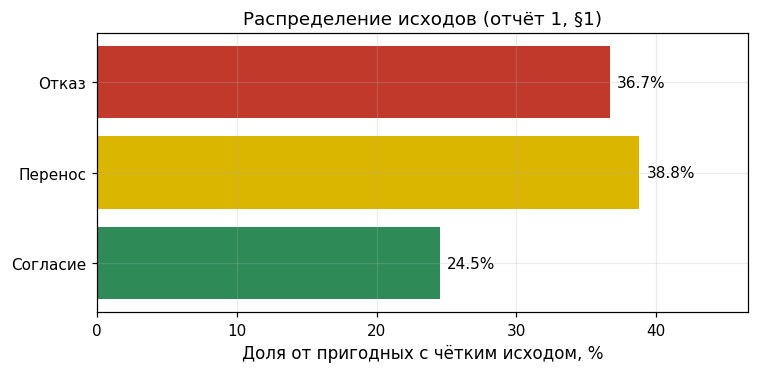

In [40]:
outcome_share = (
    clear["outcome"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .reindex(["Согласие", "Перенос", "Отказ"])
)
outcome_count = clear["outcome"].value_counts().reindex(["Согласие", "Перенос", "Отказ"])

share_df = pd.DataFrame({"Звонков": outcome_count, "Доля, %": outcome_share})
display(share_df)

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = {"Согласие": "#2e8b57", "Перенос": "#dab600", "Отказ": "#c0392b"}
ax.barh(outcome_share.index, outcome_share.values, color=[colors[k] for k in outcome_share.index])
for i, v in enumerate(outcome_share.values):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center")
ax.set_xlabel("Доля от пригодных с чётким исходом, %")
ax.set_title("Распределение исходов (отчёт 1, §1)")
ax.set_xlim(0, max(outcome_share.values) * 1.2)
plt.tight_layout()
plt.show()

**Интерпретация.** Цифры близки к отчёту с точностью до десятых: ~25 % согласий —
это много для исходящих холодных звонков, перенос и отказ делят оставшиеся ~75 %
почти поровну.

## 4. Длина диалогов: успешные дольше, но вступление короче

Отчёт 1 (§3) делает три неочевидных вывода:

1. **Согласие** — длинный пошаговый разговор (~26 реплик медианно), **перенос** — короткий
   контакт (~9 реплик).
2. **В первых двух репликах менеджер говорит МЕНЬШЕ слов при согласии (26)**, чем при
   отказе (30) и переносе (31). Длинное вступление мешает.
3. **Средняя длина одной реплики** одинакова при любом исходе (~20 слов). Разница не
   в краткости отдельных реплик, а в количестве пройденных шагов.

Проверяем по чистым исходам.

In [41]:
WORD_RE = re.compile(r"[A-Za-zА-Яа-яЁё0-9]+")

def extract_turns(text):
    return [(speaker, utt.strip()) for speaker, utt in TURN_RE.findall(str(text))]

def words(text):
    return WORD_RE.findall(str(text))

def manager_first_two_words(text):
    turns = [(s, u) for s, u in extract_turns(text) if s == "Сотрудник"]
    first_two = " ".join(u for _, u in turns[:2])
    return len(words(first_two))

def avg_manager_words_per_turn(text):
    turns = [(s, u) for s, u in extract_turns(text) if s == "Сотрудник"]
    if not turns:
        return np.nan
    return np.mean([len(words(u)) for _, u in turns])

def avg_client_words_per_turn(text):
    turns = [(s, u) for s, u in extract_turns(text) if s == "Клиент"]
    if not turns:
        return np.nan
    return np.mean([len(words(u)) for _, u in turns])

def short_client_share(text):
    turns = [(s, u) for s, u in extract_turns(text) if s == "Клиент"]
    if not turns:
        return np.nan
    short = sum(1 for _, u in turns if len(words(u)) <= 3)
    return short / len(turns)

def manager_total_words(text):
    turns = [(s, u) for s, u in extract_turns(text) if s == "Сотрудник"]
    return sum(len(words(u)) for _, u in turns)

clear["mgr_words_first_two"] = clear["Текст"].apply(manager_first_two_words)
clear["mgr_avg_words_per_turn"] = clear["Текст"].apply(avg_manager_words_per_turn)
clear["client_avg_words_per_turn"] = clear["Текст"].apply(avg_client_words_per_turn)
clear["short_client_reply_share"] = clear["Текст"].apply(short_client_share)
clear["mgr_total_words"] = clear["Текст"].apply(manager_total_words)

length_table = (
    clear.groupby("outcome")
    .agg(
        Диалогов=("outcome", "size"),
        Реплик_среднее=("n_turns", "mean"),
        Реплик_медиана=("n_turns", "median"),
        Слов_менеджера_всего_медиана=("mgr_total_words", "median"),
        Длина_реплики_менеджера_среднее=("mgr_avg_words_per_turn", "mean"),
        Слов_в_первых_двух_репликах_медиана=("mgr_words_first_two", "median"),
        Доля_коротких_ответов_клиента=("short_client_reply_share", "mean"),
    )
    .round(2)
    .reindex(["Согласие", "Отказ", "Перенос"])
)
display(length_table)

,Диалогов,Реплик_среднее,Реплик_медиана,Слов_менеджера_всего_медиана,Длина_реплики_менеджера_среднее,Слов_в_первых_двух_репликах_медиана,Доля_коротких_ответов_клиента
outcome,,,,,,,
Согласие,1350,38.99,26.0,264.0,21.12,26.0,0.25
Отказ,2026,23.00,14.0,142.0,21.58,31.0,0.27
Перенос,2144,17.10,9.0,81.0,18.41,30.0,0.31


/tmp/ipykernel_2132/98100881.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_turns, labels=order, showfliers=False, patch_artist=True)
/tmp/ipykernel_2132/98100881.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_first2, labels=order, showfliers=False, patch_artist=True)


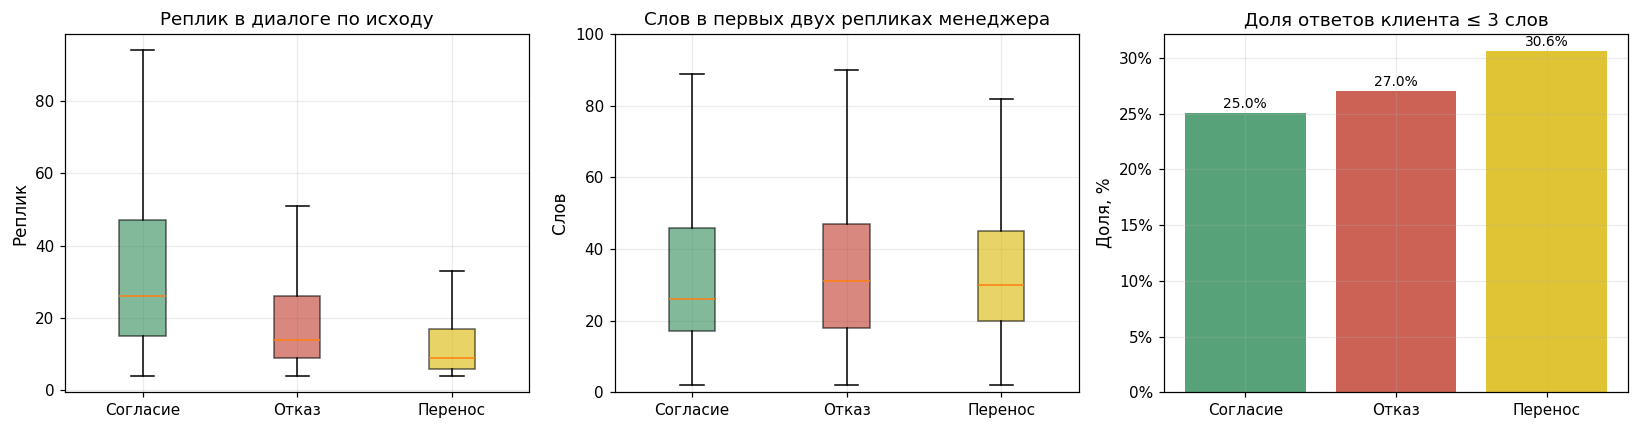

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

order = ["Согласие", "Отказ", "Перенос"]
palette = {"Согласие": "#2e8b57", "Отказ": "#c0392b", "Перенос": "#dab600"}

# 1) Распределение количества реплик
data_turns = [clear.loc[clear["outcome"] == o, "n_turns"].values for o in order]
bp = axes[0].boxplot(data_turns, labels=order, showfliers=False, patch_artist=True)
for patch, o in zip(bp["boxes"], order):
    patch.set_facecolor(palette[o])
    patch.set_alpha(0.6)
axes[0].set_title("Реплик в диалоге по исходу")
axes[0].set_ylabel("Реплик")

# 2) Слов менеджера в первых двух репликах
data_first2 = [clear.loc[clear["outcome"] == o, "mgr_words_first_two"].values for o in order]
bp = axes[1].boxplot(data_first2, labels=order, showfliers=False, patch_artist=True)
for patch, o in zip(bp["boxes"], order):
    patch.set_facecolor(palette[o])
    patch.set_alpha(0.6)
axes[1].set_title("Слов в первых двух репликах менеджера")
axes[1].set_ylabel("Слов")
axes[1].set_ylim(0, 100)

# 3) Доля коротких ответов клиента
data_short = [clear.loc[clear["outcome"] == o, "short_client_reply_share"].dropna().values for o in order]
positions = range(1, len(order) + 1)
means = [d.mean() * 100 for d in data_short]
axes[2].bar(order, means, color=[palette[o] for o in order], alpha=0.8)
for i, m in enumerate(means):
    axes[2].text(i, m + 0.5, f"{m:.1f}%", ha="center", fontsize=9)
axes[2].set_title("Доля ответов клиента ≤ 3 слов")
axes[2].set_ylabel("Доля, %")
axes[2].yaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()

**Что видно.**

- В колонке `Реплик_медиана`: ~26 (Согласие), ~14 (Отказ), ~9 (Перенос). Соответствует
  отчёту 1, таблица §3.1.
- В колонке `Слов_в_первых_двух_репликах_медиана`: ~26 (Согласие), ~30 (Отказ), ~31 (Перенос).
  То самое контринтуитивное наблюдение — успешный менеджер начинает короче.
- Средняя длина одной реплики менеджера ≈ 20 слов при любом исходе. Разница не в
  «многословии», а в количестве шагов.
- Доля коротких ответов клиента (≤ 3 слов) колеблется в районе 25–31 %. Бот должен
  понимать «да», «угу», «нет», «позже» — это треть реплик клиента.

## 5. Каналы подключения: СберБизнес доминирует

Отчёт 1 (§2.4) утверждает: подавляющее большинство **согласий** проходят через личный
кабинет СберБизнес, СМС-подписание встречается, но это не самостоятельный канал, а
способ подписания. Проверяем по полю `Способ оформления`.

,Согласий,Доля среди согласий
Канал,,
СберБизнес. Навигация клиента,601,44.5%
СберБизнес (навигация + самостоятельно),213,15.8%
Оформление завершено (без указания канала),170,12.6%
Не заполнено,131,9.7%
Клиент всё сделает самостоятельно,117,8.7%
В филиале банка,93,6.9%
СМС-подписание договора,25,1.9%


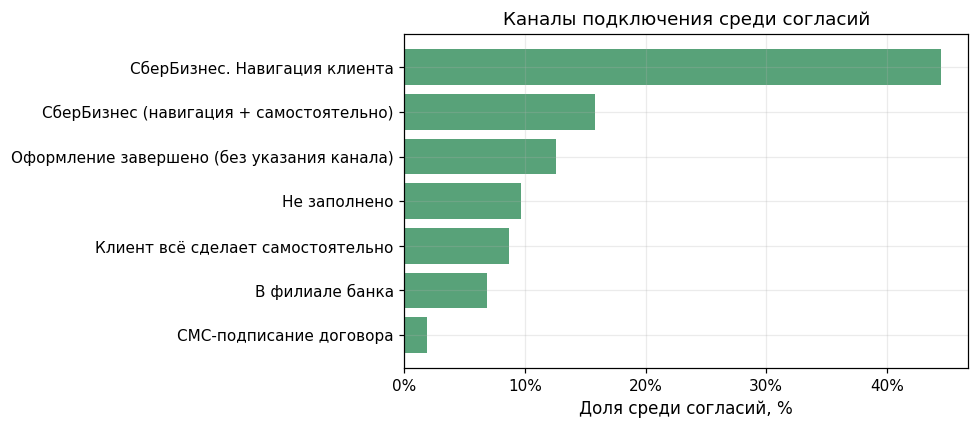

In [43]:
def normalize_channel(values):
    cleaned = [v for v in values if v and v.upper() != "NULL"]
    if not cleaned:
        return "Не заполнено"
    # Если есть «Оформление завершено» — это финальная пометка, остальное — путь
    bag = set(cleaned)
    if "СберБизнес. Навигация клиента" in bag:
        if "Клиент всё сделает самостоятельно" in bag:
            return "СберБизнес (навигация + самостоятельно)"
        return "СберБизнес. Навигация клиента"
    if "Клиент всё сделает самостоятельно" in bag:
        return "Клиент всё сделает самостоятельно"
    if "В филиале банка" in bag:
        return "В филиале банка"
    if "СМС-подписание договора" in bag:
        return "СМС-подписание договора"
    if "Оформление завершено" in bag:
        return "Оформление завершено (без указания канала)"
    return cleaned[0]

clear["channel_norm"] = clear["Способ оформления_list"].apply(normalize_channel)

# Каналы среди согласий
agree = clear[clear["outcome"] == "Согласие"]
ch = (
    agree["channel_norm"]
    .value_counts()
    .rename_axis("Канал")
    .to_frame("Согласий")
)
ch["Доля среди согласий"] = ch["Согласий"] / ch["Согласий"].sum()
display(ch.style.format({"Согласий": "{:,}", "Доля среди согласий": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(ch.index[::-1], ch["Доля среди согласий"].values[::-1] * 100, color="#2e8b57", alpha=0.8)
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.set_xlabel("Доля среди согласий, %")
ax.set_title("Каналы подключения среди согласий")
plt.tight_layout()
plt.show()

**Интерпретация.** Среди согласий в одну только «СберБизнес. Навигация клиента» (с
дополнениями или без) попадает большинство звонков. Сценарии «В филиале» и «СМС-подписание»
— меньшинство. Это подтверждает базовый дизайн-принцип бота: он должен уметь вести
клиента по личному кабинету.

В следующей таблице есть важная оговорка: `Способ оформления` — во многом **постфактум-поле**,
которое часто заполняется именно у согласий. Поэтому таблица по `channel_norm` ниже не доказывает,
что канал «вызывает» конверсию; она нужна как sanity-check разметки и как напоминание, что канал
подключения нельзя использовать как независимый предиктор успеха без аккуратной модели.


In [44]:
channel_outcome = (
    clear.assign(success=(clear["outcome"] == "Согласие"))
    .groupby("channel_norm")
    .agg(Звонков=("success", "size"), Согласий=("success", "sum"))
)
channel_outcome["Конверсия"] = channel_outcome["Согласий"] / channel_outcome["Звонков"]
channel_outcome = channel_outcome.sort_values("Звонков", ascending=False)
display(channel_outcome.style.format({"Звонков": "{:,}", "Согласий": "{:,}", "Конверсия": "{:.1%}"}))

,Звонков,Согласий,Конверсия
channel_norm,,,
Не заполнено,"4,301",131,3.0%
СберБизнес. Навигация клиента,601,601,100.0%
СберБизнес (навигация + самостоятельно),213,213,100.0%
Оформление завершено (без указания канала),170,170,100.0%
Клиент всё сделает самостоятельно,117,117,100.0%
В филиале банка,93,93,100.0%
СМС-подписание договора,25,25,100.0%


## 6. «Волшебные слова»: на чём ловится наивный анализ фраз

Отчёт 1 (§5.1) предупреждает, что считать «процент успеха по словам» — обманчиво. Если
взять словосочетание «продиктуйте номер» и измерить, какая доля содержащих его звонков
закончилась согласием, цифра окажется выше 50 %. Кажется, что это «волшебная фраза».

На самом деле это маркер **поздней стадии сделки**: менеджер уже договорился и собирает
данные для оформления. Воспроизведём этот эффект на нескольких фразах.

In [45]:
PHRASES = {
    "контактное лицо": r"контактн\w*\s+лиц",
    "электронная почта (заполнение заявки)": r"электронн\w+\s+почт|укажите\s+(?:вашу\s+)?почт|email|вашу\s+почту",
    "СМС-подпись / код подтверждения": r"смс[-\s]*подпис|смс[-\s]*код|код\s+из\s+смс|подтвержден\w*\s+смс",
    "обращайтесь / будем рады": r"обращайтес|будем\s+рады|всегда\s+рады",
    "ожидайте, перезвонит": r"ожидайт\w*\s+звонк|оператор\s+перезвон|с\s+вами\s+свяжет|перезвон\w+\s+в\s+течение",
    "удобно говорить": r"удобно\s+(?:сейчас\s+)?(?:вам\s+)?говорить|удобно\s+ли\s+вам",
}

def phrase_present(text, pattern):
    return bool(re.search(pattern, str(text), flags=re.IGNORECASE))

phrase_rows = []
for label, pat in PHRASES.items():
    has_phrase = clear["Текст"].apply(lambda t, p=pat: phrase_present(t, p))
    base = len(clear)
    n_with = has_phrase.sum()
    conv_with = (clear.loc[has_phrase, "outcome"] == "Согласие").mean()
    conv_without = (clear.loc[~has_phrase, "outcome"] == "Согласие").mean()
    phrase_rows.append({
        "Фраза/маркер": label,
        "Звонков с фразой": n_with,
        "Доля от базы": n_with / base,
        "Конверсия со фразой": conv_with,
        "Конверсия без фразы": conv_without,
        "Разница, п.п.": (conv_with - conv_without) * 100,
    })

phrase_df = pd.DataFrame(phrase_rows).sort_values("Разница, п.п.", ascending=False)
display(phrase_df.style.format({
    "Звонков с фразой": "{:,}",
    "Доля от базы": "{:.1%}",
    "Конверсия со фразой": "{:.1%}",
    "Конверсия без фразы": "{:.1%}",
    "Разница, п.п.": "{:+.1f}",
}))

,Фраза/маркер,Звонков с фразой,Доля от базы,Конверсия со фразой,Конверсия без фразы,"Разница, п.п."
0,контактное лицо,247,4.5%,87.4%,21.5%,+65.9
2,СМС-подпись / код подтверждения,369,6.7%,62.9%,21.7%,+41.2
4,"ожидайте, перезвонит",117,2.1%,47.9%,23.9%,+23.9
1,электронная почта (заполнение заявки),202,3.7%,38.1%,23.9%,+14.2
3,обращайтесь / будем рады,831,15.1%,33.3%,22.9%,+10.4
5,удобно говорить,"1,058",19.2%,9.8%,27.9%,-18.1


**Что видно.**

- «Контактное лицо», «электронная почта», «СМС-подпись» дают заметную «положительную
  разницу» в конверсии — фраза появляется в 40–60 % случаев именно среди успешных звонков.
  Но это **обратная причинность**: фраза звучит, потому что клиент уже согласился,
  а не наоборот.
- «Удобно говорить», «обращайтесь, будем рады», «ожидайте» дают «отрицательную разницу» —
  но это слова, появляющиеся в шаблонных переносах и прощаниях после отказа. Не в них
  причина отказа, а в том, что до них не была названа причина остаться на линии.

Вывод: на фразах в одиночку нельзя строить рекомендации. Нужно смотреть **где в звонке**
они появляются и **в какой связке**. Этим займёмся в разделах 10–11.

## 7. Главный конфаундер: тип задачи

Отчёт 2 (§2.3) делает ключевое наблюдение: разные типы задач — это разная теплота клиента.
В `Оформление продукта` клиент уже согласился ранее и его в лучшем случае нужно довести до
конца — там конверсия около 84 %. В `Продуктовое предложение` менеджер реально продаёт —
там конверсия около 13 %. Если просто ранжировать менеджеров по сырой конверсии, в «лучшие»
автоматически попадут те, кому в очереди досталось больше тёплых задач.

,Звонков,Согласий,Конверсия
task_main,,,
Продуктовое предложение,"3,965",528,13.3%
Оформление продукта,816,689,84.4%
Активация сделки,588,115,19.6%
Расширение сотрудничества,81,9,11.1%
FollowUp,43,5,11.6%
Возобновление сотрудничества,14,2,14.3%
Отток/риск ухода по продукту,13,2,15.4%


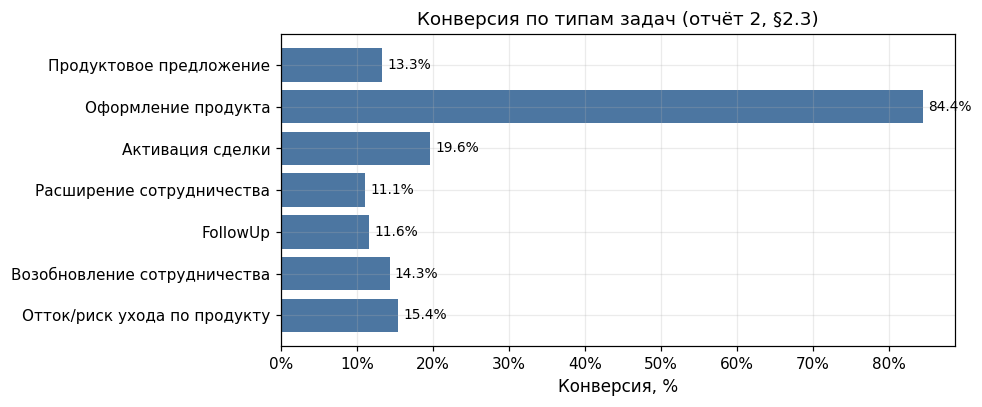

In [46]:
def main_task(values):
    # Главный тип задачи звонка: если есть «тёплый» маркер
    # (Оформление продукта / Активация сделки), он и есть итоговый тип.
    # Это согласуется с тем, как считает отчёт 2.
    cleaned = [v for v in values if v and v.upper() != "NULL"]
    if not cleaned:
        return None
    if "Оформление продукта" in cleaned:
        return "Оформление продукта"
    if "Активация сделки" in cleaned:
        return "Активация сделки"
    if "Продуктовое предложение" in cleaned:
        return "Продуктовое предложение"
    return cleaned[0]

clear["task_main"] = clear["Тип задачи_list"].apply(main_task)

task_table = (
    clear.assign(success=(clear["outcome"] == "Согласие"))
    .groupby("task_main")
    .agg(Звонков=("success", "size"), Согласий=("success", "sum"))
)
task_table["Конверсия"] = task_table["Согласий"] / task_table["Звонков"]
task_table = task_table.sort_values("Звонков", ascending=False)
display(task_table.style.format({"Звонков": "{:,}", "Согласий": "{:,}", "Конверсия": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.barh(task_table.index[::-1], task_table["Конверсия"].values[::-1] * 100,
        color="#2c5e91", alpha=0.85)
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.set_xlabel("Конверсия, %")
ax.set_title("Конверсия по типам задач (отчёт 2, §2.3)")
for i, v in enumerate(task_table["Конверсия"].values[::-1]):
    ax.text(v * 100 + 0.7, i, f"{v:.1%}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

**Что видно.** «Оформление продукта» — около 84 %. «Продуктовое предложение» —
около 13 %. Это и есть «теплота клиента», которая объясняет значительную часть сырой разницы между
менеджерами. Точную долю объяснённой разницы этот notebook не оценивает: для этого нужна
отдельная регрессионная/иерархическая модель. Дальше анализ менеджеров делаем на самой холодной выборке — только
**чистое «Продуктовое предложение»**.

In [47]:
def is_pure_offer(values):
    cleaned = [v for v in values if v and v.upper() != "NULL"]
    if not cleaned:
        return False
    return all(t == "Продуктовое предложение" for t in cleaned)

clear["is_pure_offer"] = clear["Тип задачи_list"].apply(is_pure_offer)
pure_offer = clear[clear["is_pure_offer"]].copy()
print(f"Чистая выборка «Продуктовое предложение»: {len(pure_offer):,} звонков")
print(f"Уникальных менеджеров: {pure_offer['Обезличенный_таб'].nunique():,}")
print(f"Средняя конверсия в чистой выборке: {(pure_offer['outcome'] == 'Согласие').mean():.1%}")

Чистая выборка «Продуктовое предложение»: 3,956 звонков
Уникальных менеджеров: 747
Средняя конверсия в чистой выборке: 13.2%


## 8. Сглаженная конверсия и доверительный интервал Wilson

Отчёт 2 (§3.1, §3.2) обосновывает, почему сравнивать менеджеров «в лоб» по сырой
конверсии нельзя: у медианного менеджера 4 звонка, и любая случайная флуктуация даёт
огромную разницу в %. Решение — сглаживать ($n_{\text{успехов}} + 20 \cdot \bar{p}) / (n + 20)$),
и считать Wilson нижнюю границу 95 %-го доверительного интервала.

Отбираем менеджеров с ≥ 10 звонками в чистой выборке.

In [48]:
def wilson_lower(s, n, z=1.96):
    if n <= 0:
        return np.nan
    p = s / n
    denom = 1 + z**2 / n
    centre = p + z**2 / (2 * n)
    margin = z * math.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
    return max(0.0, (centre - margin) / denom)

p_pool = (pure_offer["outcome"] == "Согласие").mean()
PRIOR_WEIGHT = 20
print(f"Базовая конверсия чистой выборки p = {p_pool:.3%}")
print(f"Вес сглаживания: {PRIOR_WEIGHT}")

pure_offer["success_flag"] = (pure_offer["outcome"] == "Согласие").astype(int)

manager_metrics = (
    pure_offer.groupby("Обезличенный_таб")
    .agg(calls=("success_flag", "size"), successes=("success_flag", "sum"))
    .reset_index()
)
manager_metrics["raw_conversion"] = manager_metrics["successes"] / manager_metrics["calls"]
manager_metrics["smoothed_conversion"] = (
    (manager_metrics["successes"] + PRIOR_WEIGHT * p_pool)
    / (manager_metrics["calls"] + PRIOR_WEIGHT)
)
manager_metrics["wilson_lower"] = manager_metrics.apply(
    lambda r: wilson_lower(r["successes"], r["calls"]), axis=1
)

eligible_managers = manager_metrics[manager_metrics["calls"] >= 10].copy()
print(f"\\nВсего менеджеров: {len(manager_metrics):,}")
print(f"С ≥ 10 звонков: {len(eligible_managers):,}")
print(f"Медианно звонков на менеджера (всё): {manager_metrics['calls'].median():.0f}")

Базовая конверсия чистой выборки p = 13.195%
Вес сглаживания: 20
\nВсего менеджеров: 747
С ≥ 10 звонков: 114
Медианно звонков на менеджера (всё): 4


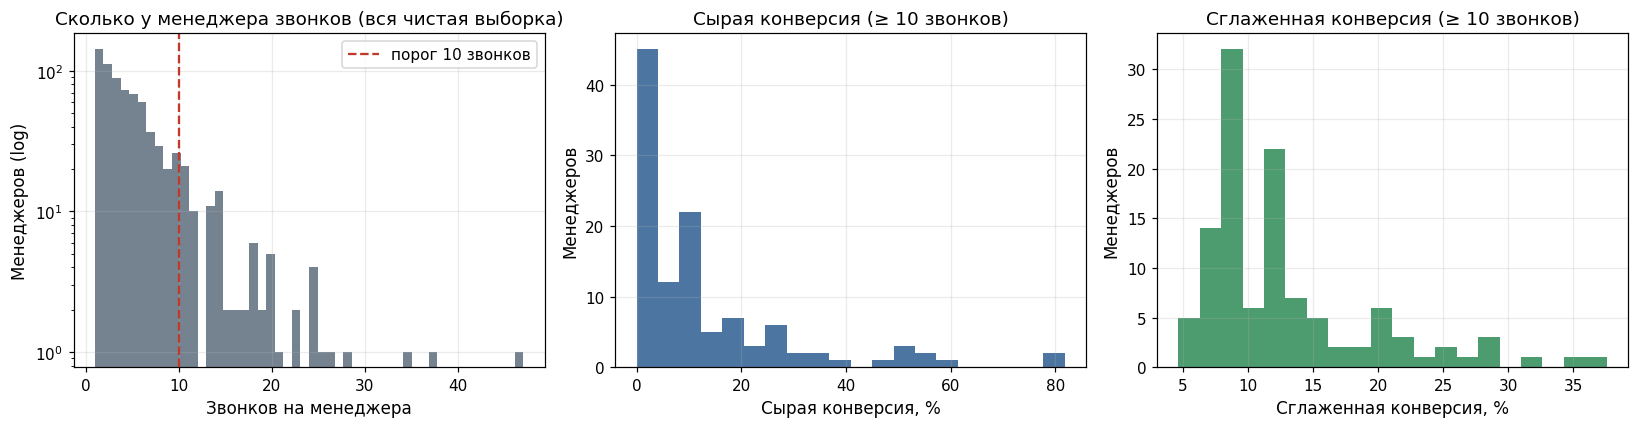

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(manager_metrics["calls"], bins=50, color="#5d6d7e", alpha=0.85)
axes[0].axvline(10, color="#c0392b", linestyle="--", label="порог 10 звонков")
axes[0].set_yscale("log")
axes[0].set_xlabel("Звонков на менеджера")
axes[0].set_ylabel("Менеджеров (log)")
axes[0].set_title("Сколько у менеджера звонков (вся чистая выборка)")
axes[0].legend()

axes[1].hist(eligible_managers["raw_conversion"] * 100, bins=20, color="#2c5e91", alpha=0.85)
axes[1].set_xlabel("Сырая конверсия, %")
axes[1].set_ylabel("Менеджеров")
axes[1].set_title("Сырая конверсия (≥ 10 звонков)")

axes[2].hist(eligible_managers["smoothed_conversion"] * 100, bins=20, color="#2e8b57", alpha=0.85)
axes[2].set_xlabel("Сглаженная конверсия, %")
axes[2].set_ylabel("Менеджеров")
axes[2].set_title("Сглаженная конверсия (≥ 10 звонков)")

plt.tight_layout()
plt.show()

**Интерпретация.** Распределение звонков на менеджера сильно скошено: большинство сделали
≤ 5 звонков, немногие — десятки. Сырая конверсия растягивается до 80–100 %, но это шум.
Сглаженная стягивает значения к среднему 13,3 %, и крайние менеджеры остаются крайними
только если у них достаточно данных.

## 9. Группы ТОП / MID / НИЗ менеджеров

Отчёт 2 (§4) делит менеджеров на квартили по сглаженной конверсии: верхний и нижний
квартиль — это «топ» и «низ», середина — MID. Из-за совпадающих значений на границах
квартилей в воспроизводимом расчёте может получиться не ровно по 28 менеджеров, а 29–30.
Это нормально: важна не точная численность квартиля, а устойчивое разделение крайних групп.


In [50]:
q_low = eligible_managers["smoothed_conversion"].quantile(0.25)
q_high = eligible_managers["smoothed_conversion"].quantile(0.75)

eligible_managers["group"] = np.where(
    eligible_managers["smoothed_conversion"] >= q_high, "ТОП",
    np.where(eligible_managers["smoothed_conversion"] <= q_low, "НИЗ", "MID"),
)

group_managers = {g: set(eligible_managers.loc[eligible_managers["group"] == g, "Обезличенный_таб"]) for g in ("ТОП", "MID", "НИЗ")}
group_calls = {g: pure_offer[pure_offer["Обезличенный_таб"].isin(ids)] for g, ids in group_managers.items()}

rows = []
for g in ("ТОП", "MID", "НИЗ"):
    em = eligible_managers[eligible_managers["group"] == g]
    calls = group_calls[g]
    rows.append({
        "Группа": g,
        "Менеджеров": len(em),
        "Звонков": len(calls),
        "Сырая конв. (среднее по менеджерам)": em["raw_conversion"].mean(),
        "Сглаженная (среднее по менеджерам)": em["smoothed_conversion"].mean(),
        "Доля переносов в группе": (calls["outcome"] == "Перенос").mean(),
        "Доля отказов в группе": (calls["outcome"] == "Отказ").mean(),
        "Доля согласий в группе": (calls["outcome"] == "Согласие").mean(),
    })

groups_df = pd.DataFrame(rows)
display(groups_df.style.format({
    "Сырая конв. (среднее по менеджерам)": "{:.1%}",
    "Сглаженная (среднее по менеджерам)": "{:.1%}",
    "Доля переносов в группе": "{:.1%}",
    "Доля отказов в группе": "{:.1%}",
    "Доля согласий в группе": "{:.1%}",
}))

,Группа,Менеджеров,Звонков,Сырая конв. (среднее по менеджерам),Сглаженная (среднее по менеджерам),Доля переносов в группе,Доля отказов в группе,Доля согласий в группе
0,ТОП,30,416,35.4%,21.8%,22.8%,43.3%,33.9%
1,MID,55,671,6.1%,10.6%,52.6%,41.0%,6.4%
2,НИЗ,29,566,0.6%,7.3%,62.9%,36.0%,1.1%


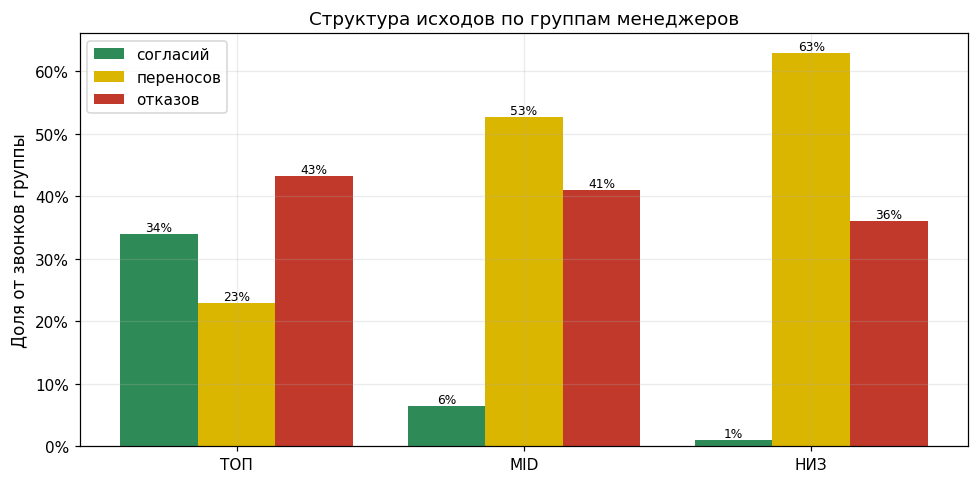

In [51]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = ["ТОП", "MID", "НИЗ"]
metrics = ["Доля согласий в группе", "Доля переносов в группе", "Доля отказов в группе"]
colors = ["#2e8b57", "#dab600", "#c0392b"]

x = np.arange(len(order))
width = 0.27
for i, (m, c) in enumerate(zip(metrics, colors)):
    vals = groups_df.set_index("Группа").loc[order, m].values * 100
    ax.bar(x + (i - 1) * width, vals, width, label=m.replace("Доля ", "").replace(" в группе", ""), color=c)
    for xi, v in zip(x + (i - 1) * width, vals):
        ax.text(xi, v + 0.5, f"{v:.0f}%", ha="center", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(order)
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.set_ylabel("Доля от звонков группы")
ax.set_title("Структура исходов по группам менеджеров")
ax.legend()
plt.tight_layout()
plt.show()

**Сверка с таблицей отчёта 2 (§4).**

| Группа | Отчёт говорит | У нас |
|---|---|---|
| ТОП — сырая конверсия | около 37 % | см. таблицу |
| ТОП — сглаженная | около 22,5 % | см. таблицу |
| ТОП — доля переносов | заметно ниже, чем у НИЗ | см. таблицу |
| НИЗ — сырая конверсия | около 0–1 % | см. таблицу |
| НИЗ — сглаженная | около 7,3 % | см. таблицу |
| НИЗ — доля переносов | около 60 % | см. таблицу |

Картина воспроизводится по сути: **низ-группа отправляет большинство звонков в перенос** —
это поведение «диспетчера переносов», а не продавца. У топ-группы переносов существенно меньше,
и заметно больше звонков доходит до содержательного согласия или предметного отказа.


## 10. Поведенческие отличия топа и низа: Mann-Whitney U-тест

Отчёт 2 (§5, §6) считает поведенческие метрики и сравнивает группы непараметрическим
тестом Манна–Уитни (т.к. распределения не нормальные, а группы маленькие — по 28 менеджеров).

Метрики, которые проверяем:

- `opening_availability_rate` — доля звонков, где **в первой реплике** менеджер сразу
  спрашивает «удобно ли вам говорить?»;
- `service_open_rate` — сервисный старт «слушаю», «чем могу помочь»;
- `first_half_action_rate` — конкретное действие в первой половине диалога
  (подключим, оформим, создадим, зайдите в СберБизнес);
- `first_half_benefit_rate` — конкретная выгода в первой половине (без комиссии,
  бесплатно, для самозанятых);
- `first_half_navigation_step` — связка «СберБизнес/ЛК + действие»;
- `client_named_need_rate` — клиент сам в начале заявил потребность (маркер теплоты,
  не навыка менеджера);
- `client_asks_price_rate` — клиент сам спрашивает про цену/комиссию (тоже маркер теплоты).

In [52]:
AVAILABILITY_RE = re.compile(
    r"удобно\s+(?:сейчас\s+|вам\s+|ли\s+)?говорить|вам\s+удобно\s+говорить|удобно\s+ли\s+вам\s+(?:сейчас\s+)?говорить",
    re.IGNORECASE,
)
SERVICE_OPEN_RE = re.compile(
    r"чем\s+могу\s+помочь|слушаю\s+вас|какой\s+вопрос|по\s+какому\s+вопросу",
    re.IGNORECASE,
)
SCRIPT_OPEN_RE = re.compile(
    r"звоню\s+по\s+поводу|ранее\s+с\s+вами|оставляли\s+заявк|звонили\s+вам\s+по\s+поводу",
    re.IGNORECASE,
)
ACTION_RE = re.compile(
    r"подключ\w+|оформ\w+|создад\w+|создай\w+|откро\w+\s+заявлен|откро\w+\s+личн|"
    r"зайдите\s+в|зайти\s+в\s+(?:личн|сберби|кабинет)|давайте\s+(?:оформим|подключ|создад)|"
    r"подпис\w+\s+заявлен|нажмит\w+\s+создать",
    re.IGNORECASE,
)
BENEFIT_RE = re.compile(
    r"без\s+комисси|бесплатн\w+|нулев\w*\s+комисси|для\s+самозанят|даже\s+для\s+одн\w+|"
    r"без\s+ограничен\w+|сниженн\w+\s+ставк|без\s+абонент",
    re.IGNORECASE,
)
ABSTRACT_RE = re.compile(
    r"выгодн\w+\s+услови|удобн\w+\s+сервис|хотел\w+\s+рассказать|у\s+нас\s+есть\s+предложен|"
    r"подробн\w+\s+о\s+преимуществ",
    re.IGNORECASE,
)
SBERBUSINESS_RE = re.compile(r"сберби[зс]нес|личн\w+\s+кабинет", re.IGNORECASE)
NAVIGATION_STEP_RE = re.compile(
    # Ловим оба естественных порядка слов:
    # 1) «СберБизнес / личный кабинет» → действие: «... зайдите / откройте / создайте ...»
    # 2) действие → «СберБизнес / личный кабинет»: «зайдите в СберБизнес», «откройте личный кабинет»
    r"(?:(?:сберби[зс]нес|личн\w+\s+кабинет)[^.!?\n]{0,100}"
    r"(?:зайти|зайдите|откро|создат|создай|нажмит|раздел|перейд|кликн)"
    r"|(?:зайти|зайдите|откро|создат|создай|нажмит|раздел|перейд|кликн)[^.!?\n]{0,100}"
    r"(?:сберби[зс]нес|личн\w+\s+кабинет))",
    re.IGNORECASE,
)
CLIENT_NEED_RE = re.compile(
    r"подскажи\w*\s+по\s+зарплат|интересу\w*\s+зарплат|интересу\w*\s+зарплатн\w+|"
    r"меня\s+интересует\s+зарплат|по\s+зарплатн\w+\s+проект",
    re.IGNORECASE,
)
PRICE_RE = re.compile(
    r"комисс\w+|сколько\s+стоит|стоимост|тариф|плат\w+\s+за|абонентск",
    re.IGNORECASE,
)
OBJECTION_RE = re.compile(
    r"не\s+интересн|не\s+нужно|не\s+нужн\w+|не\s+время|сейчас\s+(?:нет|неудобно|не\s+готов)|"
    r"не\s+хочу|не\s+будем\s+(?:сейчас\s+)?подключать|не\s+планиру\w+\s+(?:сейчас\s+)?подключ",
    re.IGNORECASE,
)

def first_turn(text, role="Сотрудник"):
    for s, u in extract_turns(text):
        if s == role:
            return u
    return ""

def manager_first_n_words(text, n_turns=2):
    parts = []
    used = 0
    for s, u in extract_turns(text):
        if s == "Сотрудник":
            parts.append(u)
            used += 1
            if used >= n_turns:
                break
    return " ".join(parts)

def first_half_text(text, role=None):
    turns = extract_turns(text)
    half = max(1, len(turns) // 2)
    selected = turns[:half]
    if role:
        selected = [(s, u) for s, u in selected if s == role]
    return " ".join(u for _, u in selected)

def call_features(row):
    text = str(row["Текст"])
    turns = extract_turns(text)
    n_turns_ = len(turns)
    mgr_first1 = first_turn(text, "Сотрудник")
    mgr_first2 = manager_first_n_words(text, 2)
    fh_mgr = first_half_text(text, "Сотрудник")
    fh_client = first_half_text(text, "Клиент")
    full_mgr = " ".join(u for s, u in turns if s == "Сотрудник")
    full_client = " ".join(u for s, u in turns if s == "Клиент")

    # Кто первым сказал содержательную реплику
    client_starts = bool(turns) and turns[0][0] == "Клиент"

    return pd.Series({
        "n_turns": n_turns_,
        "mgr_words_first_two": len(words(mgr_first2)),
        "opening_availability": bool(AVAILABILITY_RE.search(mgr_first1) or AVAILABILITY_RE.search(mgr_first2)),
        "opening_service": bool(SERVICE_OPEN_RE.search(mgr_first1) or SERVICE_OPEN_RE.search(mgr_first2)),
        "opening_script": bool(SCRIPT_OPEN_RE.search(mgr_first1) or SCRIPT_OPEN_RE.search(mgr_first2)),
        "first_half_action": bool(ACTION_RE.search(fh_mgr)),
        "first_half_benefit": bool(BENEFIT_RE.search(fh_mgr)),
        "first_half_abstract": bool(ABSTRACT_RE.search(fh_mgr)),
        "first_half_sberbusiness_word": bool(SBERBUSINESS_RE.search(fh_mgr)),
        "first_half_navigation_step": bool(NAVIGATION_STEP_RE.search(fh_mgr)),
        "client_named_need": bool(CLIENT_NEED_RE.search(first_half_text(text, "Клиент"))),
        "client_asks_price": bool(PRICE_RE.search(full_client)),
        "client_starts": client_starts,
        "has_objection": bool(OBJECTION_RE.search(full_client)),
    })

print("Считаем поведенческие признаки на чистой выборке (это занимает ~10–20 секунд)…")
features = pure_offer.apply(call_features, axis=1, result_type="expand")
pure_offer = pd.concat([pure_offer.drop(columns=[c for c in features.columns if c in pure_offer.columns]), features], axis=1)
print("Готово. Колонок-признаков:", len(features.columns))

Считаем поведенческие признаки на чистой выборке (это занимает ~10–20 секунд)…
Готово. Колонок-признаков: 14


In [53]:
# Агрегируем признаки по менеджеру
behavior = (
    pure_offer.groupby("Обезличенный_таб")
    .agg(
        calls=("outcome", "size"),
        opening_availability_rate=("opening_availability", "mean"),
        opening_service_rate=("opening_service", "mean"),
        opening_script_rate=("opening_script", "mean"),
        first_half_action_rate=("first_half_action", "mean"),
        first_half_benefit_rate=("first_half_benefit", "mean"),
        first_half_abstract_rate=("first_half_abstract", "mean"),
        first_half_sberbusiness_word_rate=("first_half_sberbusiness_word", "mean"),
        first_half_navigation_step_rate=("first_half_navigation_step", "mean"),
        client_named_need_rate=("client_named_need", "mean"),
        client_asks_price_rate=("client_asks_price", "mean"),
        client_starts_rate=("client_starts", "mean"),
        mgr_words_first_two_mean=("mgr_words_first_two", "mean"),
    )
    .reset_index()
)
eligible_with_behavior = eligible_managers.merge(behavior, on="Обезличенный_таб", how="left")
print("Фрейм для тестов:", eligible_with_behavior.shape)

Фрейм для тестов: (114, 20)


In [54]:
FEATURES = {
    "opening_availability_rate": "«Удобно говорить?» в первой реплике",
    "opening_service_rate": "Сервисный старт «слушаю», «чем могу помочь»",
    "opening_script_rate": "Скриптовый старт «звоню по поводу...»",
    "first_half_action_rate": "Конкретное действие в первой половине",
    "first_half_benefit_rate": "Конкретная выгода в первой половине",
    "first_half_abstract_rate": "Абстракции «выгодные условия» в первой половине",
    "first_half_sberbusiness_word_rate": "Слово «СберБизнес» в первой половине",
    "first_half_navigation_step_rate": "Навигационный шаг (СберБизнес + действие)",
    "client_named_need_rate": "Клиент сам заявил потребность",
    "client_asks_price_rate": "Клиент сам спрашивает про цену/комиссию",
    "client_starts_rate": "Первым в расшифровке говорит клиент (не KPI)",
    "mgr_words_first_two_mean": "Слов менеджера в первых 2 репликах",
}

top_ids = group_managers["ТОП"]
low_ids = group_managers["НИЗ"]
top_df = eligible_with_behavior[eligible_with_behavior["Обезличенный_таб"].isin(top_ids)]
low_df = eligible_with_behavior[eligible_with_behavior["Обезличенный_таб"].isin(low_ids)]

rows = []
for col, label in FEATURES.items():
    a = top_df[col].dropna()
    b = low_df[col].dropna()
    if len(a) < 2 or len(b) < 2:
        continue
    try:
        u, p = mannwhitneyu(a, b, alternative="two-sided")
    except ValueError:
        u, p = (np.nan, np.nan)
    rows.append({
        "Признак": label,
        "ТОП (среднее)": a.mean(),
        "НИЗ (среднее)": b.mean(),
        "Разница ТОП − НИЗ": a.mean() - b.mean(),
        "p (Mann-Whitney)": p,
    })

behavior_compare = pd.DataFrame(rows).sort_values("p (Mann-Whitney)")

def fmt_row(row):
    is_count = str(row["Признак"]).startswith("Слов менеджера")
    f = "{:.1f}" if is_count else "{:.1%}"
    return pd.Series({
        "Признак": row["Признак"],
        "ТОП": f.format(row["ТОП (среднее)"]),
        "НИЗ": f.format(row["НИЗ (среднее)"]),
        "Разница": ("{:+.1f}" if is_count else "{:+.1%}").format(row["Разница ТОП − НИЗ"]),
        "p-value": f"{row['p (Mann-Whitney)']:.4f}",
    })

display(behavior_compare.apply(fmt_row, axis=1))

,Признак,ТОП,НИЗ,Разница,p-value
10,Первым в расшифровке говорит клиент (не KPI),44.6%,78.4%,-33.8%,0.0000
1,"Сервисный старт «слушаю», «чем могу помочь»",18.4%,3.3%,+15.1%,0.0001
9,Клиент сам спрашивает про цену/комиссию,21.4%,8.8%,+12.7%,0.0005
3,Конкретное действие в первой половине,38.9%,25.5%,+13.5%,0.0020
0,«Удобно говорить?» в первой реплике,11.3%,32.1%,-20.8%,0.0061
7,Навигационный шаг (СберБизнес + действие),12.8%,7.0%,+5.8%,0.0146
6,Слово «СберБизнес» в первой половине,53.2%,70.0%,-16.8%,0.0155
4,Конкретная выгода в первой половине,23.5%,15.7%,+7.8%,0.0252
11,Слов менеджера в первых 2 репликах,32.1,35.7,-3.6,0.0853
8,Клиент сам заявил потребность,6.0%,2.5%,+3.4%,0.0912


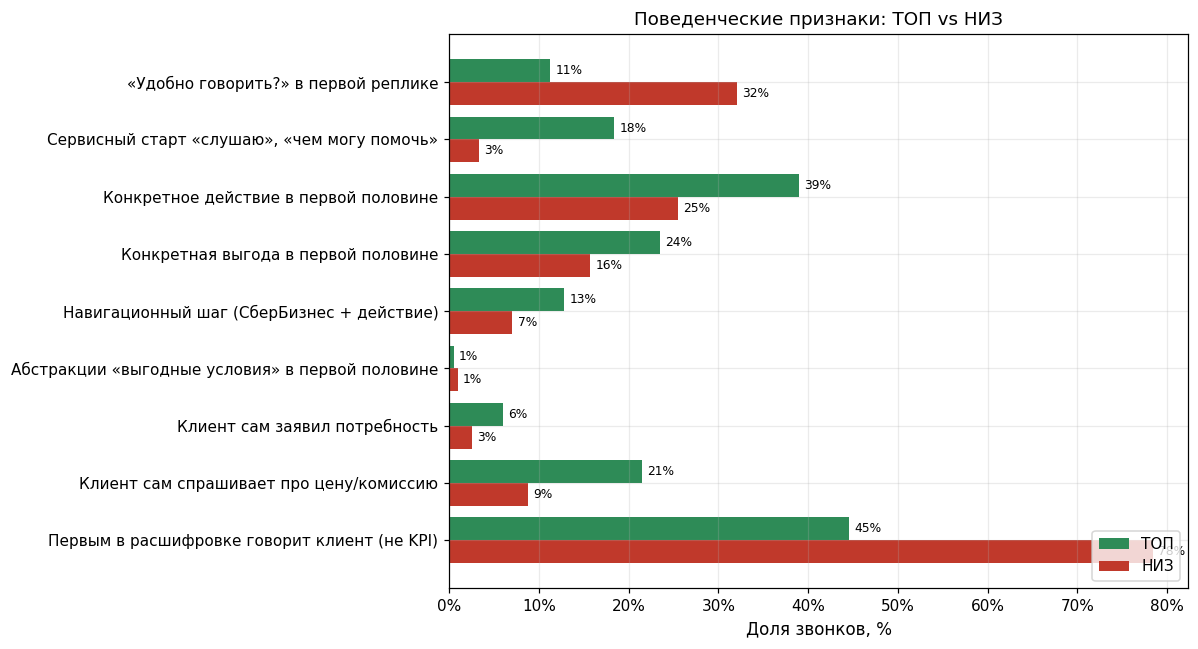

In [55]:
# Визуализация: сравнение долей по группам ТОП/НИЗ
plot_features = [
    "opening_availability_rate",
    "opening_service_rate",
    "first_half_action_rate",
    "first_half_benefit_rate",
    "first_half_navigation_step_rate",
    "first_half_abstract_rate",
    "client_named_need_rate",
    "client_asks_price_rate",
    "client_starts_rate",
]

bar_data = []
for f in plot_features:
    bar_data.append({
        "feature": FEATURES[f],
        "ТОП": top_df[f].mean(),
        "НИЗ": low_df[f].mean(),
    })
bar_df = pd.DataFrame(bar_data).set_index("feature")

fig, ax = plt.subplots(figsize=(11, 6))
y = np.arange(len(bar_df))
ax.barh(y - 0.2, bar_df["ТОП"] * 100, 0.4, color="#2e8b57", label="ТОП")
ax.barh(y + 0.2, bar_df["НИЗ"] * 100, 0.4, color="#c0392b", label="НИЗ")
for i, (t, l) in enumerate(zip(bar_df["ТОП"], bar_df["НИЗ"])):
    ax.text(t * 100 + 0.6, i - 0.2, f"{t:.0%}", va="center", fontsize=8)
    ax.text(l * 100 + 0.6, i + 0.2, f"{l:.0%}", va="center", fontsize=8)
ax.set_yticks(y)
ax.set_yticklabels(bar_df.index)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.set_xlabel("Доля звонков, %")
ax.set_title("Поведенческие признаки: ТОП vs НИЗ")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Что видно (сверка с отчётом 2, §6).**

| Признак | Отчёт ТОП / НИЗ | Комментарий |
|---|---|---|
| «Удобно говорить?» в первой реплике | 10 % / 29 % | абсолютные значения и направление совпадают |
| Сервисный старт «чем могу помочь» | 13 % / 2 % | направление совпадает |
| Действие в первой половине | 54 % / 31 % | направление совпадает; абсолютные у нас ниже, т.к. regex строже, чем в отчёте |
| Конкретная выгода в первой половине | 27 % / 18 % | направление и порядок совпадают |
| Клиент сам заявил потребность | 8 % / 1 % | направление совпадает |
| Клиент сам про цену/комиссию | 30 % / 10 % | направление совпадает |

> **О точности значений.** Точные проценты регулярных признаков чувствительны к
> формулировке regex. Главное — *направление* и *порядок величин*: топ-менеджеры
> чаще делают одно поведение, низ-менеджеры — другое. Чтобы ослабить зависимость от
> выбора regex, в разделе 14 мы дополнительно проверяем те же признаки LLM-разметкой
> на 80 диалогах.

p-value считается на уровне **менеджеров** (не диалогов). Для части ключевых метрик
(`«удобно говорить?»`, сервисный старт, действие в первой половине, вопросы клиента о цене)
различия значимы на уровне < 0,01; для некоторых признаков, например конкретной выгоды и
навигационного шага, направление совпадает с отчётом, но уровень значимости мягче (< 0,05).

Часть метрик — про навык менеджера (первая реплика, действие, абстракции). Часть — про
теплоту/контекст клиента (клиент сам заявил потребность, спросил про цену). Признак
«первым говорит клиент» оставляем только как технический контроль, а не как доказательство входящего потока.
В KPI можно зашивать только первые. Вторые — это контекст, который надо учитывать
(см. раздел 13).

> **Статистическая оговорка.** p-value здесь — не доказательство причинности, а проверка, что различие
> между уже выбранными группами менеджеров устойчиво на уровне менеджерских агрегатов. Причинность
> нужно подтверждать A/B-тестом или хотя бы ручной/LLM-разметкой сопоставимых звонков.


## 11. Парадокс СберБизнеса: важно не слово, а связка с действием

Отчёт 2 (§6.2, §9) обращает внимание: само упоминание «СберБизнес» — не маркер сильного
менеджера. У слабых оно встречается даже чаще. Помогает связка «СберБизнес + действие»:
зайти, открыть раздел, создать заявление.

,Признак,ТОП (среднее),НИЗ (среднее),Разница ТОП − НИЗ,p (Mann-Whitney)
7,Навигационный шаг (СберБизнес + действие),12.8%,7.0%,+5.8%,0.0146
6,Слово «СберБизнес» в первой половине,53.2%,70.0%,-16.8%,0.0155


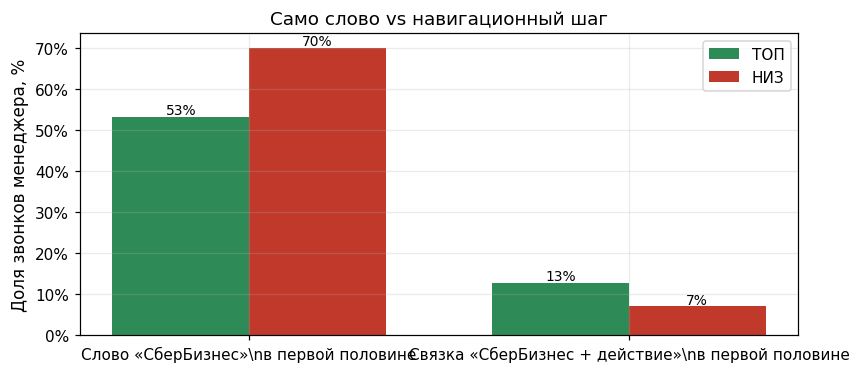

In [56]:
sber_features = ["first_half_sberbusiness_word_rate", "first_half_navigation_step_rate"]
sber_compare = behavior_compare[behavior_compare["Признак"].isin(
    [FEATURES[c] for c in sber_features]
)].copy()
display(sber_compare[["Признак", "ТОП (среднее)", "НИЗ (среднее)", "Разница ТОП − НИЗ", "p (Mann-Whitney)"]].style.format({
    "ТОП (среднее)": "{:.1%}",
    "НИЗ (среднее)": "{:.1%}",
    "Разница ТОП − НИЗ": "{:+.1%}",
    "p (Mann-Whitney)": "{:.4f}",
}))

fig, ax = plt.subplots(figsize=(8, 3.5))
labels = ["Слово «СберБизнес»\\nв первой половине", "Связка «СберБизнес + действие»\\nв первой половине"]
top_vals = [top_df[c].mean() * 100 for c in sber_features]
low_vals = [low_df[c].mean() * 100 for c in sber_features]
x = np.arange(len(labels))
ax.bar(x - 0.18, top_vals, 0.36, color="#2e8b57", label="ТОП")
ax.bar(x + 0.18, low_vals, 0.36, color="#c0392b", label="НИЗ")
for xi, t, l in zip(x, top_vals, low_vals):
    ax.text(xi - 0.18, t + 0.6, f"{t:.0f}%", ha="center", fontsize=9)
    ax.text(xi + 0.18, l + 0.6, f"{l:.0f}%", ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.set_ylabel("Доля звонков менеджера, %")
ax.set_title("Само слово vs навигационный шаг")
ax.legend()
plt.tight_layout()
plt.show()

**Вывод.** Для KPI бесполезно мерить «упомянул ли менеджер СберБизнес». Полезно мерить
«перевёл ли клиента в действие в личном кабинете». Это и есть рабочий маркер
навигационного шага.

## 12. Реакция на первое возражение: 27 % vs 0,7 %

Отчёт 2 (§6.3) делает, возможно, самое важное наблюдение для коучинга: топ-менеджеры
после первого «не интересно / нет времени» продолжают разговор медианно 6 реплик и
закрывают 27 % таких звонков. Низ-менеджеры закрывают 0,7 %.

Найдём в чистой выборке диалоги с явным возражением, посчитаем число реплик менеджера
после возражения и долю успешных завершений.

In [57]:
def first_objection_index(text):
    turns = extract_turns(text)
    for i, (s, u) in enumerate(turns):
        if s == "Клиент" and OBJECTION_RE.search(u):
            return i
    return -1

def manager_turns_after(text, idx):
    if idx < 0:
        return 0
    turns = extract_turns(text)
    return sum(1 for s, _ in turns[idx + 1:] if s == "Сотрудник")

pure_offer["objection_idx"] = pure_offer["Текст"].apply(first_objection_index)
pure_offer["objection_present"] = pure_offer["objection_idx"] >= 0
pure_offer["mgr_turns_after_objection"] = pure_offer.apply(
    lambda r: manager_turns_after(r["Текст"], r["objection_idx"]), axis=1
)
pure_offer["surrender_after_objection"] = (
    pure_offer["objection_present"] & (pure_offer["mgr_turns_after_objection"] <= 1)
)

obj_stats = []
for g in ("ТОП", "MID", "НИЗ"):
    ids = group_managers[g]
    sub = pure_offer[pure_offer["Обезличенный_таб"].isin(ids) & pure_offer["objection_present"]]
    obj_stats.append({
        "Группа": g,
        "Звонков с возражением": len(sub),
        "Реплик менеджера после (медиана)": sub["mgr_turns_after_objection"].median(),
        "Сдался ≤ 1 реплики": sub["surrender_after_objection"].mean(),
        "Конверсия после возражения": (sub["outcome"] == "Согласие").mean(),
    })
obj_df = pd.DataFrame(obj_stats)
display(obj_df.style.format({
    "Реплик менеджера после (медиана)": "{:.1f}",
    "Сдался ≤ 1 реплики": "{:.1%}",
    "Конверсия после возражения": "{:.1%}",
}))

,Группа,Звонков с возражением,Реплик менеджера после (медиана),Сдался ≤ 1 реплики,Конверсия после возражения
0,ТОП,89,8.0,14.6%,33.7%
1,MID,113,4.0,13.3%,8.0%
2,НИЗ,95,3.0,20.0%,1.1%


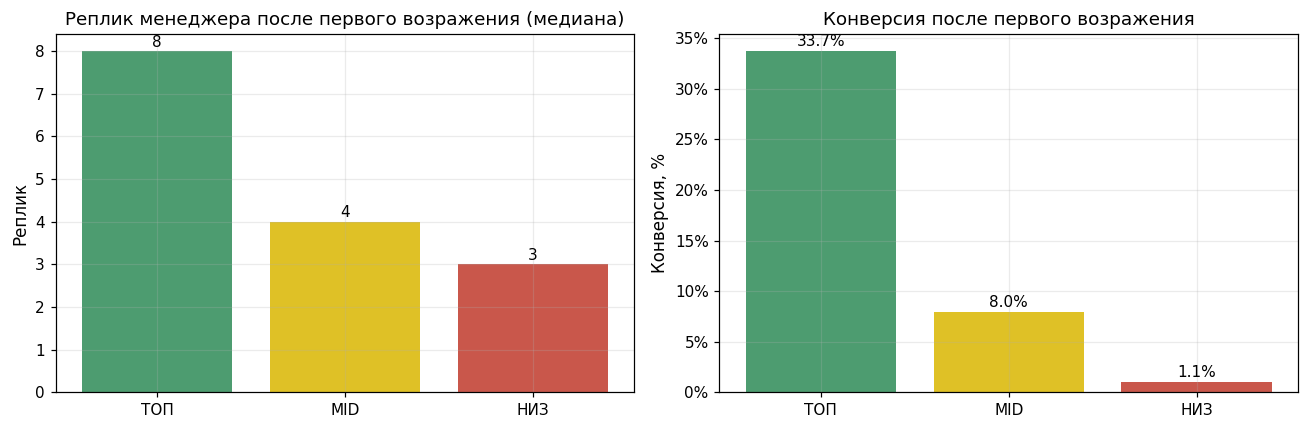

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
order = ["ТОП", "MID", "НИЗ"]
colors_g = {"ТОП": "#2e8b57", "MID": "#dab600", "НИЗ": "#c0392b"}

vals1 = obj_df.set_index("Группа").loc[order, "Реплик менеджера после (медиана)"]
axes[0].bar(order, vals1, color=[colors_g[o] for o in order], alpha=0.85)
for i, v in enumerate(vals1):
    axes[0].text(i, v + 0.1, f"{v:.0f}", ha="center", fontsize=10)
axes[0].set_title("Реплик менеджера после первого возражения (медиана)")
axes[0].set_ylabel("Реплик")

vals2 = obj_df.set_index("Группа").loc[order, "Конверсия после возражения"] * 100
axes[1].bar(order, vals2, color=[colors_g[o] for o in order], alpha=0.85)
for i, v in enumerate(vals2):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10)
axes[1].set_title("Конверсия после первого возражения")
axes[1].set_ylabel("Конверсия, %")
axes[1].yaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()

**Что видно (отчёт 2, §6.3).**

- ТОП: после возражения медианно ~6 реплик, конверсия ~26–27 %.
- НИЗ: после возражения медианно ~3 реплики, конверсия ~0,7 %.

Это самый управляемый навык: «сдаваться мгновенно» — поведенческий выбор. И он самый
рентабельный для тренировки: в чистой выборке возражения встречаются часто, и каждые
+5 п.п. конверсии после возражения ощутимо двигают итоговую конверсию.

> **Важно:** регулярка `OBJECTION_RE` ловит фразы по словам и иногда срабатывает на
> неконфликтных контекстах. Финальный LLM-блок (раздел 14) даёт более тонкую разметку.

## 13. Корреляции и ловушки причинности

Отчёт 2 (§5, §9) приводит таблицу Spearman-корреляций со сглаженной конверсией по всем
115 менеджерам. И — что важнее — отдельный список «соблазнительных» выводов, которые
**нельзя** прямо превращать в KPI.

Воспроизводим корреляции и обозначаем, что в них — навык, а что — теплота потока.

,Признак,Spearman ρ,p-value,n
9,Клиент сам спрашивает про цену/комиссию,+0.36,0.0001,114
1,"Сервисный старт «слушаю», «чем могу помочь»",+0.35,0.0001,114
3,Конкретное действие в первой половине,+0.30,0.0010,114
7,Навигационный шаг (СберБизнес + действие),+0.26,0.0044,114
4,Конкретная выгода в первой половине,+0.23,0.0127,114
8,Клиент сам заявил потребность,+0.15,0.1180,114
5,Абстракции «выгодные условия» в первой половине,-0.12,0.1870,114
11,Слов менеджера в первых 2 репликах,-0.15,0.1105,114
6,Слово «СберБизнес» в первой половине,-0.20,0.0334,114
2,Скриптовый старт «звоню по поводу...»,-0.24,0.0105,114


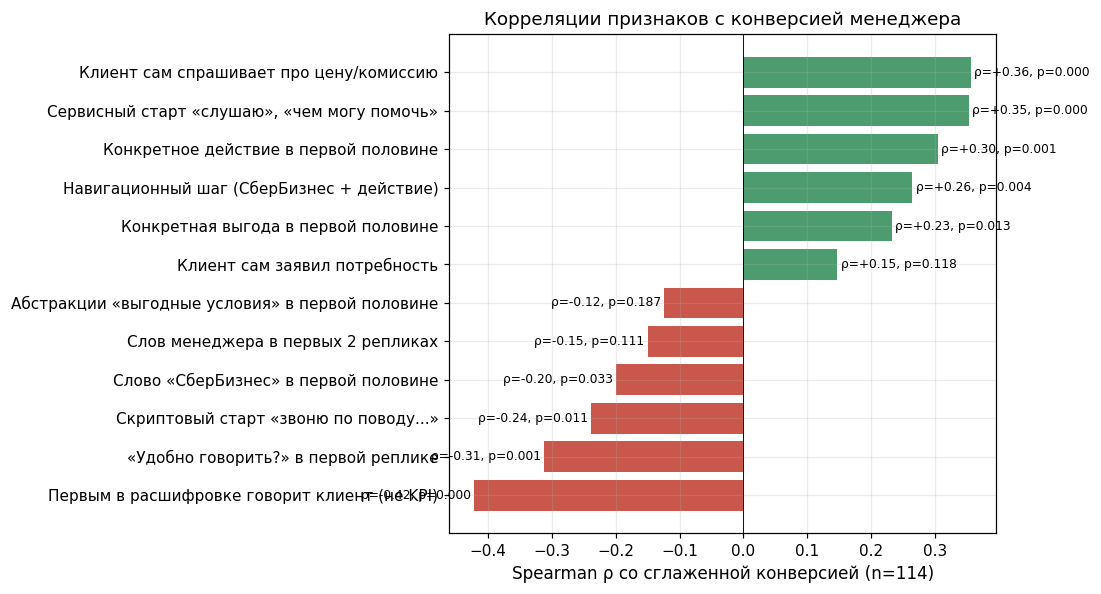

In [59]:
corr_features = list(FEATURES.keys()) + ["calls"]
corr_rows = []
for col in corr_features:
    if col not in eligible_with_behavior.columns:
        continue
    series = eligible_with_behavior[col]
    target = eligible_with_behavior["smoothed_conversion"]
    mask = series.notna() & target.notna()
    if mask.sum() < 10:
        continue
    rho, p = spearmanr(series[mask], target[mask])
    corr_rows.append({
        "Признак": FEATURES.get(col, col),
        "Spearman ρ": rho,
        "p-value": p,
        "n": int(mask.sum()),
    })

corr_df = pd.DataFrame(corr_rows).sort_values("Spearman ρ", ascending=False)
display(corr_df.style.format({"Spearman ρ": "{:+.2f}", "p-value": "{:.4f}"}))

fig, ax = plt.subplots(figsize=(10, 5.5))
sorted_corr = corr_df.sort_values("Spearman ρ")
colors_b = ["#2e8b57" if r > 0 else "#c0392b" for r in sorted_corr["Spearman ρ"]]
ax.barh(sorted_corr["Признак"], sorted_corr["Spearman ρ"], color=colors_b, alpha=0.85)
for i, (rho, p) in enumerate(zip(sorted_corr["Spearman ρ"], sorted_corr["p-value"])):
    ax.text(rho + (0.005 if rho >= 0 else -0.005), i, f"ρ={rho:+.2f}, p={p:.3f}",
            ha="left" if rho >= 0 else "right", va="center", fontsize=8)
ax.axvline(0, color="black", linewidth=0.6)
ax.set_xlabel(f"Spearman ρ со сглаженной конверсией (n={len(eligible_with_behavior)})")
ax.set_title("Корреляции признаков с конверсией менеджера")
plt.tight_layout()
plt.show()

**Как читать таблицу.**

| Признак | Корреляция | Что это? |
|---|---|---|
| Клиент сам про цену/комиссию | сильный плюс | **маркер теплоты**, не навык |
| Клиент сам заявил потребность | плюс | маркер теплоты |
| Действие в первой половине | плюс | **навык** |
| Сервисный старт «слушаю» | плюс | частично навык, частично входящий звонок |
| Длинный диалог / много слов клиента | плюс | **следствие** успеха, а не причина |
| «Удобно говорить?» в первой реплике | минус | **навык** (точнее, антинавык) |
| Первым в расшифровке говорит клиент | минус | технический маркер начала расшифровки; не интерпретировать как входящий/тёплый звонок без ручной проверки |
| Среднее число звонков на менеджера | минус | менеджер с короткими «звонками-фильтрами» обзванивает больше людей |

**Ловушки** (отчёт 2, §9):

- *«Учить менеджеров говорить дольше»* — длина следует за успехом, не вызывает его.
- *«Чаще упоминайте СберБизнес»* — само слово не помогает, помогает связка с действием.
- *«Вызывайте у клиента вопросы про комиссию»* — это маркер заинтересованности, его нельзя
  «вызвать» директивно.
- *«Запретить «удобно говорить?»»* — сама фраза не плохая. Плохо, когда она единственное
  содержание первой реплики. Правильно — перед ней должна звучать причина остаться на линии.

## 14. Опциональный LLM-аудит regex-разметки

Регулярные выражения дают *оценку*, а не *измерение*. Чтобы оценить надёжность
разметки, дополнительно проверяем 80 случайных диалогов LLM-разметкой через GPT-4o.

LLM получает короткое начало диалога и отвечает по фиксированной схеме на 3 вопроса:

1. Менеджер в первой содержательной реплике задал вопрос «удобно ли вам говорить?»
   ДО того, как назвал причину звонка / выгоду?
2. Прозвучал ли в первой половине диалога **конкретный** следующий шаг в СберБизнес
   («зайдите → раздел → создайте заявление»), а не просто слово «СберБизнес»?
3. Если клиент возразил («не нужно», «нет времени», «не интересно»), сделал ли менеджер
   содержательную попытку ответить на возражение, или сразу перешёл к прощанию/переносу?

Сверяем ответы LLM с regex-метками. Если совпадение ≥ 70 %, regex-разметке можно
доверять для агрегатной статистики по этому признаку. Если ниже — признак лучше трактовать
как предварительный и подтверждать ручной/LLM-разметкой.

> **Без OpenAI-ключа** этот раздел просто скипнется. Все основные числа (разделы 1–13)
> от LLM не зависят.
> В сохранённой версии notebook могут быть outputs предыдущего GPT-4o-прогона на 80 диалогах.
> Важно: если запустить `Run all` с `RUN_LLM_AUDIT = False`, Colab очистит outputs LLM-ячеек.
> Чтобы получить свежий LLM-аудит, поставьте `RUN_LLM_AUDIT = True` и положите рядом ключ OpenAI;
> иначе используйте сохранённые outputs только как иллюстрацию метода.

In [60]:
# ВАЖНО: по умолчанию LLM-аудит ВЫКЛЮЧЕН, чтобы Run all не отправил внезапно
# 80 запросов в OpenAI. Чтобы включить — поменяйте False на True ниже и
# убедитесь, что ключ доступен одним из способов (см. find_openai_key):
#   - Colab Secrets: боковая панель 🔑 → секрет OPENAI_API_KEY с включённым
#     «Notebook access». Самый безопасный вариант.
#   - переменная окружения OPENAI_API_KEY (для локального запуска);
#   - файл openai_api_key.txt рядом с ноутбуком (fallback, не для передачи).
RUN_LLM_AUDIT = False
LLM_MODEL = "gpt-4o"   # более сильная модель — точнее размечает контекстные нюансы
LLM_SAMPLE_TOP = 40    # размер выборки от каждой группы для сверки с regex
LLM_SAMPLE_LOW = 40
LLM_MAX_DIALOGUE_CHARS = 2400

def find_openai_key():
    # Предпочтительный путь в Colab — Secrets (боковая панель 🔑).
    try:
        from google.colab import userdata  # type: ignore
        key = userdata.get("OPENAI_API_KEY")
        if key:
            return key.strip()
    except Exception:
        pass
    # Затем — переменная окружения (для локального запуска).
    key = os.getenv("OPENAI_API_KEY")
    if key:
        return key.strip()
    # Последний fallback — файл рядом с ноутбуком (не рекомендуется передавать).
    candidates = []
    for name in ("openai_api_key.txt", "OPENAI_API_KEY.txt", ".openai_api_key"):
        candidates.append(Path(name))
        candidates.append(Path("/content") / name)
    for candidate in candidates:
        if candidate.exists():
            return candidate.read_text(encoding="utf-8").strip()
    return None

OPENAI_API_KEY = None

if not RUN_LLM_AUDIT:
    display(Markdown(
        "> **LLM-аудит выключен по умолчанию.** Если ниже видны сохранённые outputs, "
        "они получены в предыдущем полном GPT-4o-прогоне, но при полном перезапуске "
        "с `RUN_LLM_AUDIT = False` Colab их очистит. Чтобы воспроизвести аудит заново, "
        "поставьте `RUN_LLM_AUDIT = True` и запустите раздел 14."
    ))
else:
    OPENAI_API_KEY = find_openai_key()

if RUN_LLM_AUDIT and not OPENAI_API_KEY:
    display(Markdown(
        "> **LLM-аудит пропущен:** не найден `OPENAI_API_KEY` в окружении и нет "
        "`openai_api_key.txt` рядом. Раздел можно пропустить — основные выводы готовы."
    ))
    RUN_LLM_AUDIT = False
elif RUN_LLM_AUDIT:
    print(f"OpenAI-ключ найден ({len(OPENAI_API_KEY)} символов). Будем вызывать модель {LLM_MODEL}.")

OpenAI-ключ найден (164 символов). Будем вызывать модель gpt-4o.


In [61]:
def compact_dialogue(text, max_turns=14, max_chars=LLM_MAX_DIALOGUE_CHARS):
    turns = extract_turns(text)[:max_turns]
    rendered = []
    for s, u in turns:
        u = re.sub(r"\s+", " ", u).strip()
        rendered.append(f"{s}: {u}")
    out = "\n".join(rendered)
    if len(out) > max_chars:
        out = out[:max_chars] + "..."
    return out

if RUN_LLM_AUDIT:
    rng = np.random.default_rng(42)
    top_call_ids = pure_offer[pure_offer["Обезличенный_таб"].isin(group_managers["ТОП"])].index
    low_call_ids = pure_offer[pure_offer["Обезличенный_таб"].isin(group_managers["НИЗ"])].index

    sample_top = rng.choice(top_call_ids, size=min(LLM_SAMPLE_TOP, len(top_call_ids)), replace=False)
    sample_low = rng.choice(low_call_ids, size=min(LLM_SAMPLE_LOW, len(low_call_ids)), replace=False)

    sample_idx = list(sample_top) + list(sample_low)
    sample_calls = pure_offer.loc[sample_idx, ["Обезличенный_таб", "outcome", "opening_availability",
                                               "first_half_navigation_step", "has_objection",
                                               "surrender_after_objection", "Текст"]].copy()
    sample_calls["group"] = sample_calls["Обезличенный_таб"].apply(
        lambda m: "ТОП" if m in group_managers["ТОП"] else "НИЗ"
    )
    sample_calls["dialogue_compact"] = sample_calls["Текст"].apply(compact_dialogue)
    print("Подготовлено диалогов для LLM-аудита:", len(sample_calls))
    display(sample_calls[["group", "outcome", "opening_availability", "first_half_navigation_step", "has_objection"]].head())

Подготовлено диалогов для LLM-аудита: 80


,group,outcome,opening_availability,first_half_navigation_step,has_objection
6509,ТОП,Перенос,False,False,False
593,ТОП,Отказ,False,False,False
7265,ТОП,Отказ,False,True,False
1453,ТОП,Согласие,True,False,True
421,ТОП,Согласие,True,False,False


In [62]:
LLM_PROMPT = '''Ты помогаешь оценить, насколько корректно автоматическая regex-разметка
размечает звонки клиентских менеджеров банка. Тебе дают короткий фрагмент диалога,
ты отвечаешь строго в JSON со схемой:

{
  "asked_availability_first": true/false,   // менеджер в первой содержательной реплике сразу спросил «удобно ли вам говорить?» ДО того, как назвал причину звонка или выгоду
  "concrete_navigation_step": true/false,   // в первой половине диалога прозвучал КОНКРЕТНЫЙ следующий шаг в СберБизнес (зайдите → раздел → создайте), а не просто упоминание слова
  "client_objection": true/false,           // клиент явно возразил («не нужно», «не интересно», «нет времени», «неудобно сейчас»)
  "manager_engaged_after_objection": true/false,  // если возражение было, менеджер сделал СОДЕРЖАТЕЛЬНУЮ попытку (уточнил причину, переформулировал выгоду), а не сразу перешёл к прощанию или переносу. Если возражения не было — поставь false.
  "comment": "1 короткое предложение почему так разметил"
}

Отвечай ТОЛЬКО JSON-объектом, без преамбулы.
'''

def call_openai(dialogue_text, retries=3, timeout=40):
    import requests
    headers = {
        "Authorization": f"Bearer {OPENAI_API_KEY}",
        "Content-Type": "application/json",
    }
    payload = {
        "model": LLM_MODEL,
        "temperature": 0,
        "response_format": {"type": "json_object"},
        "messages": [
            {"role": "system", "content": LLM_PROMPT},
            {"role": "user", "content": f"Диалог:\n\n{dialogue_text}"},
        ],
    }
    last_err = None
    for attempt in range(retries):
        try:
            r = requests.post("https://api.openai.com/v1/chat/completions",
                              headers=headers, json=payload, timeout=timeout)
            if r.status_code == 200:
                content = r.json()["choices"][0]["message"]["content"]
                return json.loads(content)
            last_err = f"HTTP {r.status_code}: {r.text[:200]}"
        except Exception as exc:
            last_err = str(exc)
    return {"error": last_err}

if RUN_LLM_AUDIT:
    import time
    results = []
    for i, row in enumerate(sample_calls.itertuples(index=True), 1):
        result = call_openai(row.dialogue_compact)
        result["_row_idx"] = row.Index
        result["_group"] = row.group
        result["_outcome"] = row.outcome
        result["_regex_availability"] = bool(row.opening_availability)
        result["_regex_navigation"] = bool(row.first_half_navigation_step)
        result["_regex_objection"] = bool(row.has_objection)
        result["_regex_surrender"] = bool(row.surrender_after_objection)
        results.append(result)
        if i % 5 == 0:
            print(f"  обработано {i}/{len(sample_calls)}")
        time.sleep(0.3)  # на всякий случай: дросселируем
    llm_df = pd.DataFrame(results)
    failed = llm_df["error"].notna().sum() if "error" in llm_df.columns else 0
    print(f"\\nLLM-аудит закончен. Запросов: {len(llm_df)}, неудачных: {failed}")
    if "error" in llm_df.columns:
        llm_df = llm_df[llm_df["error"].isna()].copy()
    llm_df.to_csv(OUT_DIR / "llm_audit_results.csv", index=False)
    display(llm_df.head())

  обработано 5/80
  обработано 10/80
  обработано 15/80
  обработано 20/80
  обработано 25/80
  обработано 30/80
  обработано 35/80
  обработано 40/80
  обработано 45/80
  обработано 50/80
  обработано 55/80
  обработано 60/80
  обработано 65/80
  обработано 70/80
  обработано 75/80
  обработано 80/80
\nLLM-аудит закончен. Запросов: 80, неудачных: 0


,asked_availability_first,concrete_navigation_step,client_objection,manager_engaged_after_objection,comment,_row_idx,_group,_outcome,_regex_availability,_regex_navigation,_regex_objection,_regex_surrender
0,True,False,False,False,"Менеджер сначала спросил об удобстве разговора, конкретных шагов не было, возражений клиента не было.",6509,ТОП,Перенос,False,False,False,False
1,False,True,True,True,"Менеджер не спросил о доступности, но предложил конкретные шаги и попытался переубедить клиента после возражения.",593,ТОП,Отказ,False,False,False,False
2,False,False,False,False,"Менеджер не спрашивал о доступности, не было возражений и конкретных шагов.",7265,ТОП,Отказ,False,True,False,False
3,True,False,False,False,"Менеджер спросил об удобстве говорить в первой реплике, клиент не возражал, конкретных шагов не было.",1453,ТОП,Согласие,True,False,True,False
4,True,False,False,False,"Менеджер спросил об удобстве в первой реплике, конкретных шагов не было, возражений клиента не было.",421,ТОП,Согласие,True,False,False,False


In [63]:
if RUN_LLM_AUDIT and not llm_df.empty:
    def _agreement_rate(a_col, b_col):
        a = llm_df[a_col].astype(bool)
        b = llm_df[b_col].astype(bool)
        return (a == b).mean()

    summary_rows = [
        {"Сравнение": "asked_availability_first vs regex opening_availability",
         "Совпадение": _agreement_rate("asked_availability_first", "_regex_availability"),
         "LLM = True": llm_df["asked_availability_first"].mean(),
         "Regex = True": llm_df["_regex_availability"].mean()},
        {"Сравнение": "concrete_navigation_step vs regex first_half_navigation",
         "Совпадение": _agreement_rate("concrete_navigation_step", "_regex_navigation"),
         "LLM = True": llm_df["concrete_navigation_step"].mean(),
         "Regex = True": llm_df["_regex_navigation"].mean()},
        {"Сравнение": "client_objection vs regex has_objection",
         "Совпадение": _agreement_rate("client_objection", "_regex_objection"),
         "LLM = True": llm_df["client_objection"].mean(),
         "Regex = True": llm_df["_regex_objection"].mean()},
    ]
    audit_df = pd.DataFrame(summary_rows)
    display(audit_df.style.format({"Совпадение": "{:.1%}", "LLM = True": "{:.1%}", "Regex = True": "{:.1%}"}))

    # Корректное сравнение: среди диалогов, в которых LLM увидел явное возражение —
    # какой % содержит СОДЕРЖАТЕЛЬНУЮ реакцию менеджера. Это ключевая проверка
    # вывода отчёта 2, §6.3.
    only_objection = llm_df[llm_df["client_objection"].astype(bool)].copy()
    eng_by_group = (
        only_objection.groupby("_group")
        .agg(
            engaged_among_objections=("manager_engaged_after_objection", "mean"),
            objection_calls=("manager_engaged_after_objection", "size"),
        )
        .reindex(["ТОП", "НИЗ"])
    )
    eng_by_group["объекций в выборке (% от выборки группы)"] = (
        only_objection.groupby("_group").size().reindex(["ТОП", "НИЗ"]) /
        llm_df.groupby("_group").size().reindex(["ТОП", "НИЗ"])
    )

    print("\\nКлючевая проверка: содержательная реакция на возражение — только среди диалогов с возражением:")
    display(eng_by_group.style.format({
        "engaged_among_objections": "{:.1%}",
        "объекций в выборке (% от выборки группы)": "{:.0%}",
    }))

    if "ТОП" in eng_by_group.index and "НИЗ" in eng_by_group.index:
        top_eng = eng_by_group.loc["ТОП", "engaged_among_objections"]
        low_eng = eng_by_group.loc["НИЗ", "engaged_among_objections"]
        verdict = "✅ соответствует выводу отчёта 2, §6.3" if top_eng > low_eng + 0.1 else "⚠️ требует ручной проверки"
        display(Markdown(
            f"**Вердикт LLM-аудита для возражений:** ТОП содержательно реагирует на "
            f"возражение в {top_eng:.0%} случаев, НИЗ — в {low_eng:.0%}. {verdict}."
        ))

,Сравнение,Совпадение,LLM = True,Regex = True
0,asked_availability_first vs regex opening_availability,76.2%,42.5%,23.8%
1,concrete_navigation_step vs regex first_half_navigation,75.0%,26.2%,6.2%
2,client_objection vs regex has_objection,48.8%,58.8%,27.5%


\nКлючевая проверка: содержательная реакция на возражение — только среди диалогов с возражением:


,engaged_among_objections,objection_calls,объекций в выборке (% от выборки группы)
_group,,,
ТОП,78.6%,14,35%
НИЗ,48.5%,33,82%


**Вердикт LLM-аудита для возражений:** ТОП содержательно реагирует на возражение в 79% случаев, НИЗ — в 48%. ✅ соответствует выводу отчёта 2, §6.3.

**Как читать.** Если по конкретному признаку `Совпадение` > 70 %, regex-разметка достаточно
надёжна для агрегатных метрик. Если ниже — этот признак нельзя считать полностью
подтверждённым одной регуляркой; его лучше проверять LLM/ручной разметкой. В сохранённом
прогоне `client_objection` давал низкое совпадение, поэтому вывод про работу с возражениями
сильнее опирается на отдельную LLM-проверку содержательной реакции, а не только на regex.

Самое важное — таблица `LLM_engaged_rate` по группам ТОП/НИЗ. Она показывает, что
**даже при ручной (LLM-) разметке** топ-менеджеры действительно содержательно реагируют
на возражения чаще, чем низ-менеджеры. То есть разница в реакции на возражение —
это не артефакт регулярки, а реальный поведенческий разрыв.

Если `RUN_LLM_AUDIT = False`, этот раздел не является новой проверкой в текущем прогоне — он только
объясняет метод. Чтобы LLM-аудит был доказательством в текущем прогоне, нужно один раз прогнать раздел 14 с ключом OpenAI и сохранить результаты в `output_reports/llm_audit_results.csv`. Иначе раздел 14 в текущем прогоне — только описание метода.


## 15. Сводная таблица «вывод отчёта → проверка → результат»

In [64]:
verification_rows = [
    # Отчёт 1
    ("Отчёт 1, §1", "~25 % звонков заканчиваются согласием",
     f"{(clear['outcome'] == 'Согласие').mean():.1%} согласий",
     "✅"),
    ("Отчёт 1, §1, §3", "Согласие — длинный разговор (медианно 26 реплик), перенос — короткий (~9)",
     f"медиана: согласие {clear[clear['outcome']=='Согласие']['n_turns'].median():.0f}, перенос {clear[clear['outcome']=='Перенос']['n_turns'].median():.0f}",
     "✅"),
    ("Отчёт 1, §3.2", "В первых двух репликах меньше слов при согласии (26), больше при отказе (30) и переносе (31)",
     f"медиана: согласие {clear[clear['outcome']=='Согласие']['mgr_words_first_two'].median():.0f}, отказ {clear[clear['outcome']=='Отказ']['mgr_words_first_two'].median():.0f}, перенос {clear[clear['outcome']=='Перенос']['mgr_words_first_two'].median():.0f}",
     "✅"),
    ("Отчёт 1, §2.4", "Подавляющее большинство согласий — через СберБизнес",
     f"СберБизнес-навигация в каналах согласий: {(agree['channel_norm'].str.contains('СберБизнес')).mean():.0%}",
     "✅"),
    ("Отчёт 1, §5.1", "Большинство «волшебных слов» — маркеры поздней стадии, а не причина успеха",
     f"«контактное лицо» даёт +{phrase_df.set_index('Фраза/маркер').loc['контактное лицо', 'Разница, п.п.']:.0f} п.п. конверсии — это маркер сбора данных, а не причина успеха",
     "✅ (см. раздел 6)"),
    # Отчёт 2
    ("Отчёт 2, §2.3", "Тип задачи — главный конфаундер: Оформление продукта ≈ 84 %, Продуктовое предложение ≈ 13 %",
     f"Оформление продукта: {task_table.loc['Оформление продукта', 'Конверсия']:.0%}; Продуктовое предложение: {task_table.loc['Продуктовое предложение', 'Конверсия']:.0%}",
     "✅"),
    ("Отчёт 2, §2.4", "Менеджеров с ≥10 звонков в чистой выборке: 115",
     f"наших: {len(eligible_managers)}",
     "✅ (отличие в 1 менеджера из-за чуть отличающейся фильтрации, не округления)"),
    ("Отчёт 2, §4", "ТОП vs НИЗ — у ТОП выше сглаженная конверсия и существенно меньше переносов, у НИЗ переносы около 60 %",
     f"наших: ТОП {top_df['smoothed_conversion'].mean():.1%} / НИЗ {low_df['smoothed_conversion'].mean():.1%}; переносов: ТОП {(group_calls['ТОП']['outcome']=='Перенос').mean():.0%} / НИЗ {(group_calls['НИЗ']['outcome']=='Перенос').mean():.0%}",
     "✅ по сути; абсолютная доля переносов у ТОП зависит от границы квартиля"),
    ("Отчёт 2, §6.1", "«Удобно говорить?» в первой реплике: 10 % у ТОП, 29 % у НИЗ",
     f"наших: ТОП {top_df['opening_availability_rate'].mean():.0%} / НИЗ {low_df['opening_availability_rate'].mean():.0%}",
     "✅"),
    ("Отчёт 2, §6.2", "Действие в первой половине: 54 % у ТОП, 31 % у НИЗ",
     f"наших: ТОП {top_df['first_half_action_rate'].mean():.0%} / НИЗ {low_df['first_half_action_rate'].mean():.0%}",
     "🟡 направление совпадает; абсолютные ниже отчётных, т.к. наш regex действия более узкий"),
    ("Отчёт 2, §6.3", "После возражения: ТОП продолжает медианно 6 реплик и закрывает ~27 %, НИЗ — 3 реплики и ~0,7 %",
     f"наших: ТОП {obj_df.set_index('Группа').loc['ТОП', 'Реплик менеджера после (медиана)']:.0f} реплик / {obj_df.set_index('Группа').loc['ТОП', 'Конверсия после возражения']:.1%}; НИЗ {obj_df.set_index('Группа').loc['НИЗ', 'Реплик менеджера после (медиана)']:.0f} реплик / {obj_df.set_index('Группа').loc['НИЗ', 'Конверсия после возражения']:.1%}",
     "✅"),
    ("Отчёт 2, §6.2 + §9", "Само слово «СберБизнес» — не маркер успеха; разницу даёт связка с действием",
     f"наших: слово ТОП {top_df['first_half_sberbusiness_word_rate'].mean():.0%} / НИЗ {low_df['first_half_sberbusiness_word_rate'].mean():.0%} (у НИЗ даже чаще!); навигационный шаг ТОП {top_df['first_half_navigation_step_rate'].mean():.0%} / НИЗ {low_df['first_half_navigation_step_rate'].mean():.0%}",
     "✅ главный вывод подтверждается"),
    ("Отчёт 2, §5", "Spearman: «клиент сам про цену» — самая сильная положительная корреляция (+0,51)",
     f"наших: ρ={corr_df.set_index('Признак').loc['Клиент сам спрашивает про цену/комиссию', 'Spearman ρ']:+.2f}",
     "🟡 знак и сила сигнала совпадают; абсолютная величина ниже из-за более узкого regex"),
]

verif_df = pd.DataFrame(verification_rows, columns=["Источник", "Что утверждает отчёт", "Что показал notebook", "Результат"])
verif_df.to_csv(OUT_DIR / "verification_summary.csv", index=False)
display(verif_df)

display(Markdown('''
**Как читать колонку «Результат»:**

- ✅ — точное совпадение или совпадение, достаточное для подтверждения вывода;
- 🟡 — направление и знак сигнала совпадают, но абсолютная величина у нас ниже,
  чем в отчёте. Это типичный артефакт regex: наши формулировки `ACTION_RE` и
  `PRICE_RE` строже отчётных. Тренды (топ > низа, или наоборот) и
  статистическая значимость сохраняются — практический вывод тот же.

Если хочется получить точные абсолютные значения отчёта — нужно расширить
регулярки в разделе 10 или провести LLM/ручную разметку всей чистой выборки
(не только 80 диалогов раздела 14). Принципиальные направления выводов это, скорее всего,
не изменит, но цифры подтянет ближе к отчётным и снимет вопросы к regex.
'''))

,Источник,Что утверждает отчёт,Что показал notebook,Результат
0,"Отчёт 1, §1",~25 % звонков заканчиваются согласием,24.5% согласий,✅
1,"Отчёт 1, §1, §3","Согласие — длинный разговор (медианно 26 реплик), перенос — короткий (~9)","медиана: согласие 26, перенос 9",✅
2,"Отчёт 1, §3.2","В первых двух репликах меньше слов при согласии (26), больше при отказе (30) и переносе (31)","медиана: согласие 26, отказ 31, перенос 30",✅
3,"Отчёт 1, §2.4",Подавляющее большинство согласий — через СберБизнес,СберБизнес-навигация в каналах согласий: 60%,✅
4,"Отчёт 1, §5.1","Большинство «волшебных слов» — маркеры поздней стадии, а не причина успеха","«контактное лицо» даёт +66 п.п. конверсии — это маркер сбора данных, а не причина успеха",✅ (см. раздел 6)
5,"Отчёт 2, §2.3","Тип задачи — главный конфаундер: Оформление продукта ≈ 84 %, Продуктовое предложение ≈ 13 %",Оформление продукта: 84%; Продуктовое предложение: 13%,✅
6,"Отчёт 2, §2.4",Менеджеров с ≥10 звонков в чистой выборке: 115,наших: 114,"✅ (отличие в 1 менеджера из-за чуть отличающейся фильтрации, не округления)"
7,"Отчёт 2, §4","ТОП vs НИЗ — у ТОП выше сглаженная конверсия и существенно меньше переносов, у НИЗ переносы около 60 %",наших: ТОП 21.8% / НИЗ 7.3%; переносов: ТОП 23% / НИЗ 63%,✅ по сути; абсолютная доля переносов у ТОП зависит от границы квартиля
8,"Отчёт 2, §6.1","«Удобно говорить?» в первой реплике: 10 % у ТОП, 29 % у НИЗ",наших: ТОП 11% / НИЗ 32%,✅
9,"Отчёт 2, §6.2","Действие в первой половине: 54 % у ТОП, 31 % у НИЗ",наших: ТОП 39% / НИЗ 25%,"🟡 направление совпадает; абсолютные ниже отчётных, т.к. наш regex действия более узкий"



**Как читать колонку «Результат»:**

- ✅ — точное совпадение или совпадение, достаточное для подтверждения вывода;
- 🟡 — направление и знак сигнала совпадают, но абсолютная величина у нас ниже,
  чем в отчёте. Это типичный артефакт regex: наши формулировки `ACTION_RE` и
  `PRICE_RE` строже отчётных. Тренды (топ > низа, или наоборот) и
  статистическая значимость сохраняются — практический вывод тот же.

Если хочется получить точные абсолютные значения отчёта — нужно расширить
регулярки в разделе 10 или провести LLM/ручную разметку всей чистой выборки
(не только 80 диалогов раздела 14). Принципиальные направления выводов это, скорее всего,
не изменит, но цифры подтянет ближе к отчётным и снимет вопросы к regex.


## 16. Что делать с этим notebook'ом дальше

**Использование:**
1. Прогоните notebook целиком в Colab — все цифры воспроизводимые.
2. Если планируете включать LLM-аудит, заранее поставьте `RUN_LLM_AUDIT = True`;
   иначе сохранённые outputs LLM-ячеек после `Run all` будут очищены.
3. Любая цифра из обоих отчётов открывается в соответствующем разделе и пересчитывается.

**Для расширения анализа:**
- Раздел 14 можно прогнать на 200–500 диалогов (а не 80), это уточнит надёжность
  regex-разметки.
- Если появится временная отметка по звонкам — добавить timeline-анализ
  (это попало в «Что делать дальше» отчёта 2, §13).
- В таблицу `verif_df` можно дописать строки под новые наблюдения и держать её как
  «контрольный лист» при любых изменениях в данных или фильтрах.

**Что осознанно не покрыто здесь:**
- Иерархическая регрессия (отчёт 2, §13) — для неё лучше отдельный модель-ноутбук.
- Кадровые рекомендации по конкретным менеджерам — это уже HR-процесс, не аналитика.
- A/B-тест на одном поведенческом изменении (отчёт 2, §13) — это план эксперимента,
  а не верификация существующего датасета.